# Trabajo Práctico Final - Inteligencia Artificial 2026

## Dataset: Iris (UCI)
## Alumno: Sosa Matias Luis 
## Docente: Moreira Pablo
---


## Etapa 1: Exploración y modelo baseline

### 1.1 Carga y análisis exploratorio (EDA)

El dataset Iris contiene 150 observaciones de flores de tres especies: *Setosa*, *Versicolor* y *Virginica*.  
Cada observación tiene 4 variables numéricas: longitud y ancho de sépalo, longitud y ancho de pétalo.  

Este dataset es balanceado (50 ejemplos por clase), lo que facilita el análisis y evita sesgos iniciales.  
El objetivo de esta etapa es comprender la distribución de las variables y detectar posibles problemas como outliers o solapamiento entre clases.

In [199]:
# Importamos librerias usadas durante la primera etapa:

"""
from sklearn.datasets import load_iris
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
"""

'\nfrom sklearn.datasets import load_iris\nimport pandas as pd\n%matplotlib inline\nimport matplotlib.pyplot as plt\nimport seaborn as sns\nfrom sklearn.model_selection import train_test_split\nfrom sklearn.linear_model import LogisticRegression\nfrom sklearn.metrics import accuracy_score, classification_report\nfrom sklearn.preprocessing import StandardScaler\n'

In [200]:
# Importamos librerias

from sklearn.datasets import load_iris
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

# Carga del dataset
iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = pd.Series(iris.target, name="species")

print(f"Tamaño total del dataset: {X.shape[0]} muestras con {X.shape[1]} características.")

# Mostrar todas las filas y columnas del DataFrame (del 1 al 150)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

df = pd.concat([X, y], axis=1)
df.head()




Tamaño total del dataset: 150 muestras con 4 características.


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


### 📌 Hallazgos iniciales del dataset Iris

#### Tamaño y estructura del dataset
- Contiene *150 muestras* de flores, cada una con *4 características numéricas (variables predictoras)*:
  - Sepal length (cm)
  - Sepal width (cm)
  - Petal length (cm)
  - Petal width (cm)
- La variable objetivo (*species*) tiene *3 clases balanceadas*:
  - Setosa (50 ejemplos)
  - Versicolor (50 ejemplos)
  - Virginica (50 ejemplos)

#### Calidad de los datos
- El dataset es pequeño y balanceado.
- No se observan valores nulos ni faltantes.
- Los rangos de las variables son consistentes y no aparecen outliers(valores atipicos) evidentes.
- Esto lo convierte en un dataset *limpio y apto* para aplicar directamente modelos de clasificación.

### 1.2 Visualización de variables

En esta parte, graficamos histogramas y scatter plots para poder observar la distribución de las variables.  

#### Histogramas

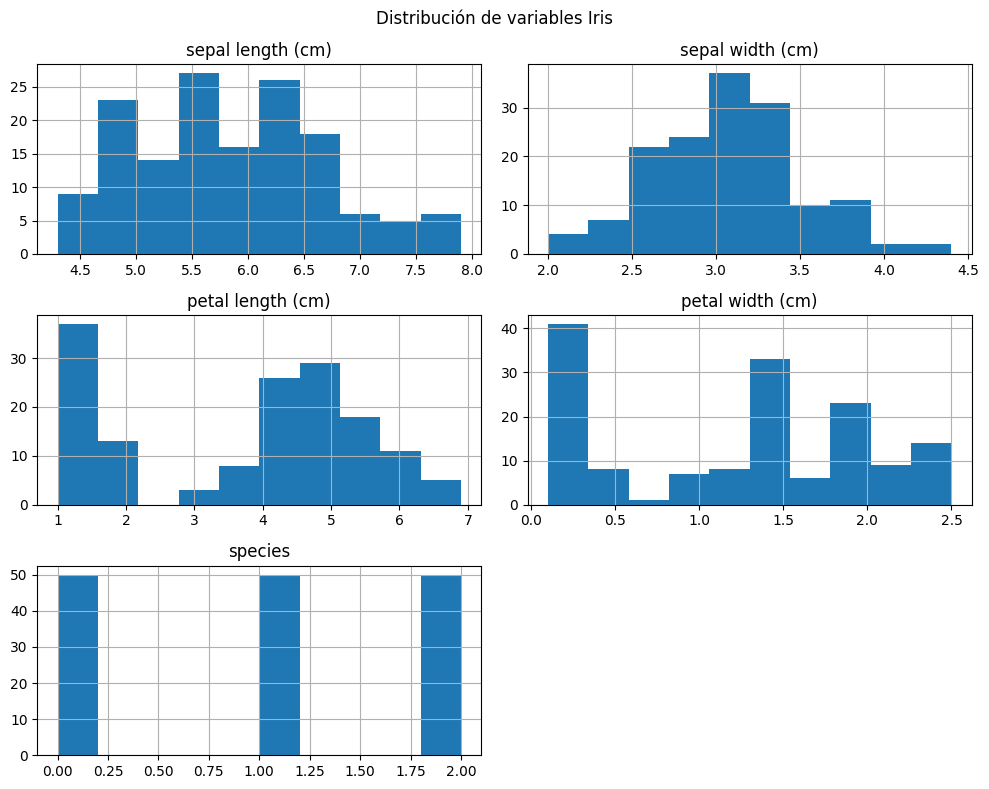

In [201]:
# Histogramas
df.hist(figsize=(10,8))
plt.suptitle("Distribución de variables Iris")
plt.tight_layout()
plt.show()

A continuacion, visualizaremos todas las combinaciones posibles contrastando las variables predictoras.

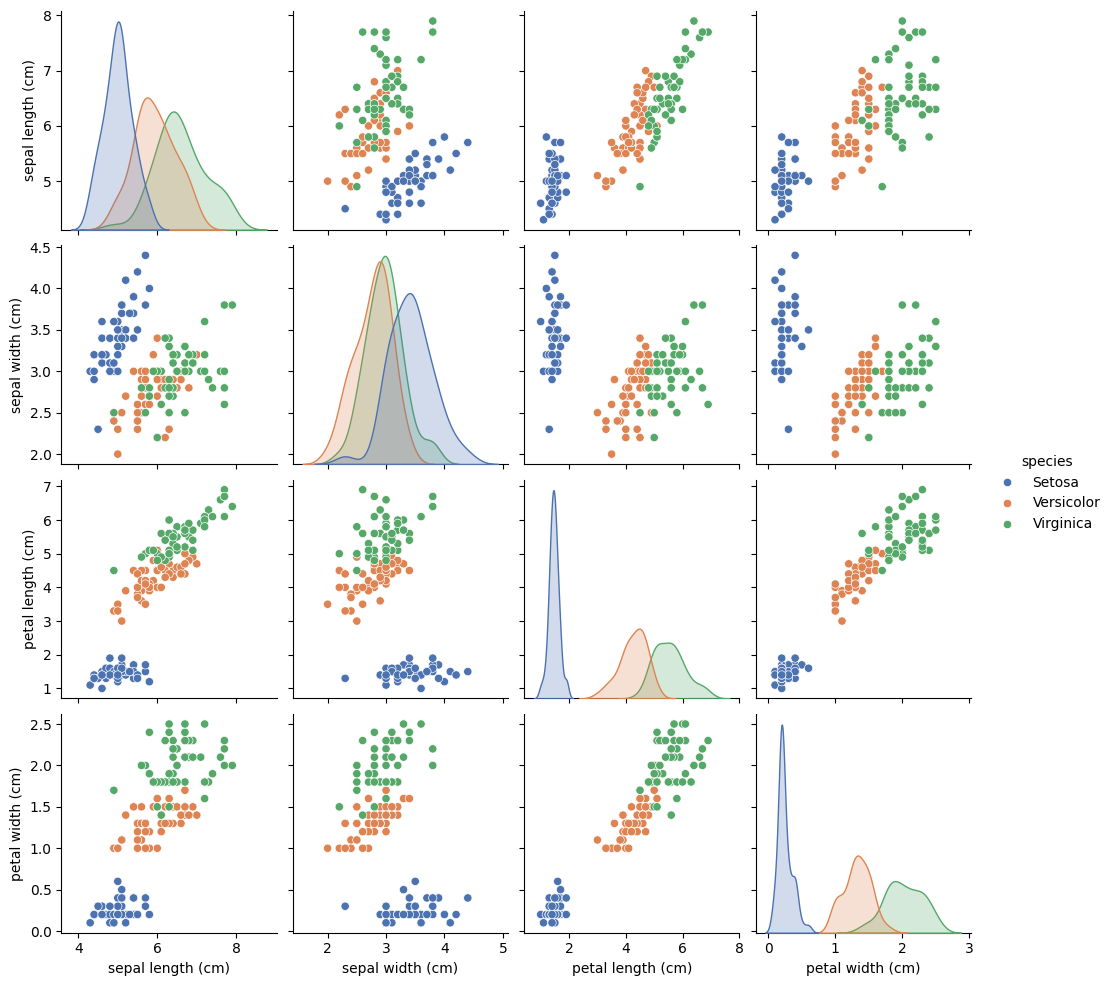

In [202]:
# Pairplot (todas las combinaciones de variables)
diccionario_especies = {0: 'Setosa', 1: 'Versicolor', 2: 'Virginica'}
df['species_name'] = df['species'].map(diccionario_especies)

# Graficamos el pairplot con la columna 'species' como hue
sns.pairplot(df.replace({"species": diccionario_especies}), hue="species", palette="deep")
plt.show()

Tomaremos como referencia de analisis estos 4 plots a continuación:

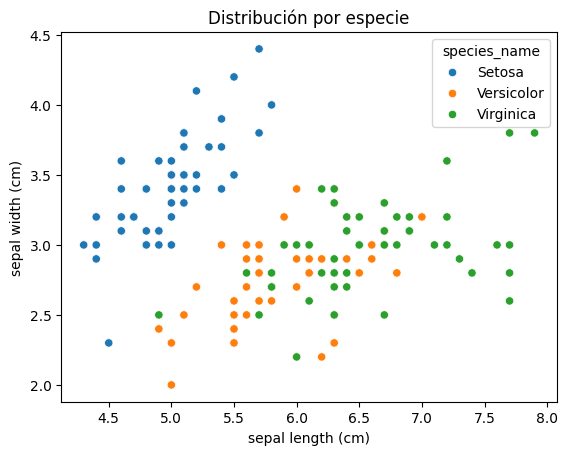

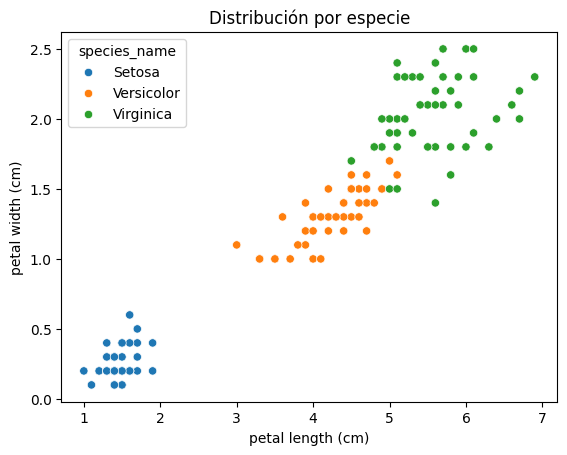

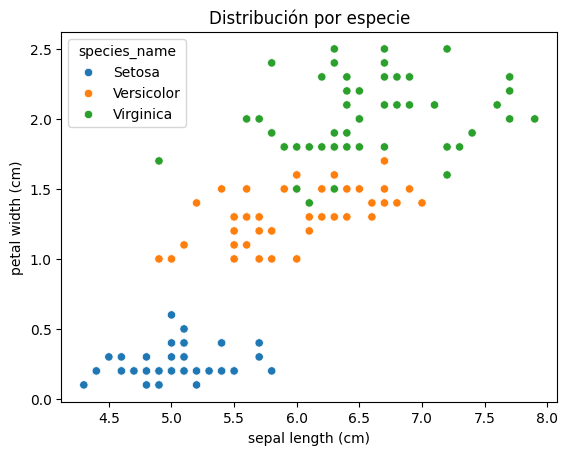

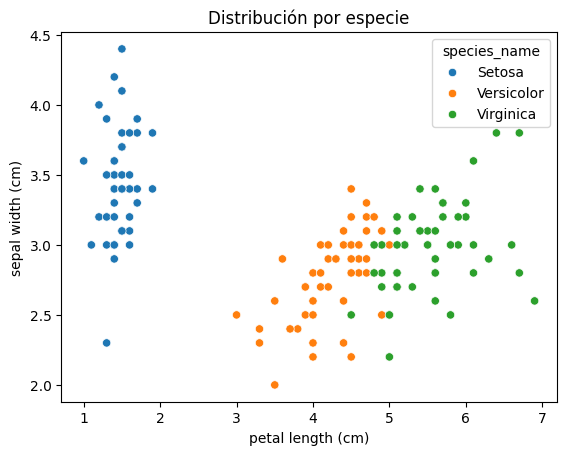

In [203]:
# Scatter plots para cada combinación de variables

sns.scatterplot(x="sepal length (cm)", y="sepal width (cm)", hue="species_name", data=df)
plt.title("Distribución por especie")
plt.show()

sns.scatterplot(x="petal length (cm)", y="petal width (cm)", hue="species_name", data=df)
plt.title("Distribución por especie")
plt.show()

sns.scatterplot(x="sepal length (cm)", y="petal width (cm)", hue="species_name", data=df)
plt.title("Distribución por especie")
plt.show()

sns.scatterplot(x="petal length (cm)", y="sepal width (cm)", hue="species_name", data=df)
plt.title("Distribución por especie")
plt.show()

El scatter plot que contrasta las dimensiones de los sépalos (`sepal length` vs. `sepal width`) permite extraer conclusiones analíticas fundamentales sobre la complejidad del espacio de características:

1. **Aislamiento Geométrico de la Clase 0 (Setosa):** Los ejemplares de la especie *Setosa* presentan un comportamiento morfológico ortogonal, caracterizado por sépalos cortos y anchos. Su dispersión espacial confirma que es **linealmente separable** del resto del conjunto de datos en este plano bidimensional.
2. **Solapamiento Crítico en Región de Frontera (Clases 1 y 2):** Las distribuciones espaciales de *Versicolor* y *Virginica* experimentan una fuerte intersección en el rango central del gráfico. 

A partir del analisis de contrastar los plots comparativos y el pairplot, podemos apreciar como la clase SETOSA se separa linealmente del resto del conjunto de datos, debido a caracteristicas propias de tener sépalos cortos y anchos. Mientras, la clase Virginica y VERSICOLOR presentan solapamiento y una interseccion fuerte que presentara a futuro el problema para aplicar los modelos en este dataset.

La evaluación final de la matriz de correlación mediante el mapa de calor permite identificar la estructura de dependencia entre las variables predictoras:

En todos los cruces marginales del gráfico (fuera de la diagonal) y de manera contundente en las funciones de densidad, la clase Setosa se posiciona como un clúster completamente aislado del resto.
Al analizar el cruce de `sepal length` vs `sepal width` (segundo gráfico de la primera fila), las nubes de puntos de Versicolor (Naranja) y Virginica (Verde) están densamente entremezcladas y solapadas en el centro. 
Esto demuestra que las dimensiones del sépalo poseen un alto sesgo y baja varianza explicativa.
Al inspeccionar el cruce de `petal length` vs `petal width` (último gráfico de la tercera fila), se observa una fuerte correlación lineal positiva (los puntos forman una diagonal ascendente muy estirada). Las distribuciones de la diagonal para los pétalos muestran que, aunque Versicolor y Virginica comparten una pequeña zona límite común, sus modas y densidades están mayormente separadas.



### 1.3 Partición de datos

Previo a aplicar un modelo baseline, realizamos la particion de los datos.
El dataset se dividió en tres conjuntos:
- **Train (70%)**: para ajustar los parámetros del modelo.
- **Dev (15%)**: para evaluar y comparar modelos durante el desarrollo.
- **Test (15%)**: reservado para la evaluación final en la Etapa 4.

Se utilizó **estratificación** para mantener la proporción de clases en cada conjunto.  
Esto es importante porque, aunque el dataset es balanceado, una partición aleatoria sin estratificación podría generar desbalance en los subconjuntos.

In [204]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, stratify=y, random_state=42)
X_dev, X_test, y_dev, y_test = train_test_split(X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42)

print("Train:", X_train.shape, "Dev:", X_dev.shape, "Test:", X_test.shape)

Train: (105, 4) Dev: (22, 4) Test: (23, 4)


### 1.4 Modelo baseline

Se implementó una **regresión logística** como modelo baseline.  
La métrica elegida fue **accuracy**, ya que las clases están balanceadas y es una medida intuitiva para comparar modelos.  




In [205]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler

# escalamos los datos
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_dev_scaled = scaler.transform(X_dev)
X_test_scaled = scaler.transform(X_test)

# Entrenamos el modelo Baseline
baseline = LogisticRegression(max_iter=200)
baseline.fit(X_train_scaled, y_train)

y_dev_pred = baseline.predict(X_dev_scaled)

# Cálculamos de métricas principales
baseline_acc = accuracy_score(y_dev, y_dev_pred)
print("MÉTRICAS DE EVALUACIÓN GLOBAL - BASELINE")
print(f"Baseline Accuracy (Dev): {baseline_acc*100:.2f}%")

# Reporte detallado de clasificación (Precision, Recall, F1-Score por clase)
print("REPORTE DE CLASIFICACIÓN DETALLADO:")
print(classification_report(y_dev, y_dev_pred, target_names=iris.target_names))




MÉTRICAS DE EVALUACIÓN GLOBAL - BASELINE
Baseline Accuracy (Dev): 86.36%
REPORTE DE CLASIFICACIÓN DETALLADO:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00         8
  versicolor       0.75      0.86      0.80         7
   virginica       0.83      0.71      0.77         7

    accuracy                           0.86        22
   macro avg       0.86      0.86      0.86        22
weighted avg       0.87      0.86      0.86        22



Analizando el reporte de clasificación luego de implementar el modelo baseline: 
El baseline alcanzó una accuracy de 86,36% en validación, lo que indica que el modelo simple ya logra una buena separación entre clases. (como los datos estan bastante agrupados en valores numericos no muy separados, es igual si escalamos o no los datos, pero para mantener el orden para futuros entrenamientos del modelo, se escalara los datos de aqui en adelante) 

El reporte de clasificación confirma la hipótesis planteada anteriormente. La especie Setosa obtiene métricas perfectas de 1.00 en Precision y Recall debido a su separabilidad lineal. Por el contrario, la caída en el rendimiento de Versicolor (por ejemplo, analizando la precisión y sus resultados($Precision = 0.75$) y Virginica ($Precision = 0.83$)) expone el impacto del solapamiento en las fronteras de los sépalos y pétalos.

Estos valores servirán como referencia para todas las etapas siguientes: debemos lograr superar el umbral del 86% del accuracy.

## Etapa 2:  Red neuronal multicapa y análisis de errores

### 2.1 Análisis de errores manual

Procedemos a inspeccionar las muestras del conjunto Dev donde el modelo Baseline (Regresión Logística) falló.
(Aclaración: la pauta solicita analizar 50 muestras mal clasificadas, pero como se aprecia anteriormente,  debido a la escasez de muestras (150) y observando que el conjunto de validación es el 15% (22 datos), primeramente haremos analisis sobre los errores disponibles que se muestren a continuación.)

In [206]:
# librerias e importaciones para la siguiente etapa:

""""
from sklearn.metrics import confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Sequential
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.regularizers import l2
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import EarlyStopping
"""

'"\nfrom sklearn.metrics import confusion_matrix\nimport tensorflow as tf\nfrom tensorflow.keras.models import Sequential\nfrom sklearn.preprocessing import StandardScaler\nimport matplotlib.pyplot as plt\nimport numpy as np\nfrom sklearn.metrics import classification_report\nfrom tensorflow.keras.layers import Dense, Dropout\nfrom tensorflow.keras.regularizers import l2\nimport matplotlib.pyplot as plt\nfrom tensorflow.keras.callbacks import EarlyStopping\n'

Total de errores encontrados en Dev: 3
================ MUESTRAS MAL CLASIFICADAS =================
| Muestra 77: Clase Real = versicolor, Predicción = virginica |
------------------------------------------------------------
| Muestra 133: Clase Real = virginica, Predicción = versicolor |
------------------------------------------------------------
| Muestra 106: Clase Real = virginica, Predicción = versicolor |
------------------------------------------------------------


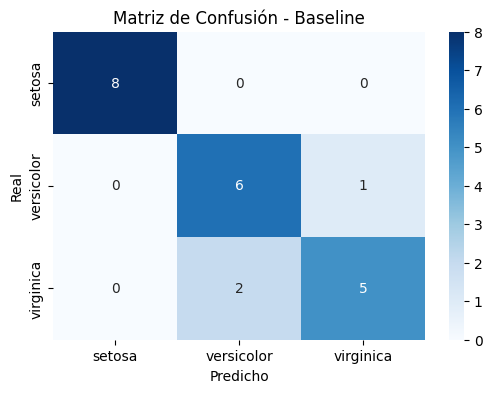

In [207]:
from sklearn.metrics import confusion_matrix

# Obtenemos predicciones del conjunto Dev
y_dev_pred = baseline.predict(X_dev_scaled)

errors_mask = y_dev_pred != y_dev
df_errors = X_dev.loc[errors_mask].copy()

# información comparativa
df_errors['Clase Real'] = y_dev.loc[errors_mask].values
df_errors['Predicción Baseline'] = y_dev_pred[errors_mask]

# errores para el análisis manual
print(f"Total de errores encontrados en Dev: {len(df_errors)}")

# muestras mal clasificadas en formato 
print(" MUESTRAS MAL CLASIFICADAS ".center(60, "="))

for idx in df_errors.index:
    real = iris.target_names[df_errors.loc[idx, 'Clase Real']]
    pred = iris.target_names[df_errors.loc[idx, 'Predicción Baseline']]
    line = f"Muestra {idx}: Clase Real = {real}, Predicción = {pred}"
    print(f"| {line:<56} |")
    print("-" * 60)
df_errors

cm = confusion_matrix(y_dev, y_dev_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.title('Matriz de Confusión - Baseline')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.show()


 El 100% de los errores se debe a la confusión entre versicolor y virginica, prediciendo 2 datos (106 y 133) como versicolor, siendo de la clase virginica, y una muestra (77) predecida como virginica, siendo realmente de la clase versicolor. 
 
 Como las características de Versicolor y Virginica se solapan en la frontera de este dataset, una línea recta propuesta por la regresión logistica del modelo es incapaz de capturar la curvatura real de los datos. El modelo simplifica excesivamente la realidad (provocando un alto sesgo(underfitting)), cometiendo un error sistemático e inevitable debido a la naturaleza de los datos.

Debido a que el modelo lineal es estable, presenta baja varianza(overfitting), ya que el modelo no presenta comportamiento erratico o disperso (los errores solamente provienen donde se presenta el solapamiento).



### 2.2 Arquitectura MLP

En esta etapa:

Para resolver nuestro problema de underfitting presente en la zona de solapamiento de la regresión logística, implementaremos una Red Neuronal multicapa, evolucionando desde el modelo lineal hacia una arquitectura profunda, implementada mediante TensorFlow/Keras.

Se configuro el modelo con 3 capas ocultas con una esquema piramidal de neuronas ($64 \rightarrow 32 \rightarrow 16$).
(¿Porque elegimos este orden de neuronas? Como tenemos apenas 4 datos de entrada y muy poquitas flores (105 en Train), al achicar el camino obligás a la red a resumir, no le dejámos espacio físico para memorizar los detalles inutiles o el ruido de cada flor; la obligás a quedarse solo con las reglas generales. Permitiendo obtener menos Overfitting, curvas más estables y mejor rendimiento. El orden 64 $\rightarrow$ 32 $\rightarrow$ 16 funciona como un filtro natural de regularización. El orden inverso le da demasiada libertad a un modelo que ya de por sí tiende a sobreajustar)

Utilizamos ReLU como función de activación en las capas ocultas y la función Softmax en la capa de salida para obtener una distribucón de probabilidad sobre las 3 clases mutuamente excluyentes.

Para calcular la función de perdida, usamos Sparse Categorical Crossentropy, ideal para problemas de clasificación multiclase.

Empleamos Adam con una tasa de aprendisaje (Learning Rate) inicial de $0.005$. (Adam nos permite reducir la perdida(loss) y la escala del Learning Rate es el tamaño del paso que da el optimizador para buscar el resultado óptimo).





En el proximo codigo, exploramos como funciona el modelo sin regularización:

In [208]:
#MLP PURA (Sin regularización)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.preprocessing import StandardScaler

# Garantizar reproducibilidad
tf.random.set_seed(42)

# Escalado Estándar con los DATOS REALES 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train) 
X_dev_scaled = scaler.transform(X_dev)
X_test_scaled = scaler.transform(X_test)       

# Función constructora de la MLP (Solo la arquitectura pura, sin regularización)
def build_iris_mlp(input_dim=4):
    model = Sequential([
        # Capa Oculta 1: 64 neuronas
        Dense(64, activation='relu', input_shape=(input_dim,)),
        
        # Capa Oculta 2: 32 neuronas
        Dense(32, activation='relu'),
        
        # Capa Oculta 3: 16 neuronas
        Dense(16, activation='relu'),
        
        # Capa de Salida: 3 clases (Especies Iris)
        Dense(3, activation='softmax')
    ])
    return model

# Instanciar el modelo puro pasando las dimensiones de entrada
model = build_iris_mlp(input_dim=4)

# Compilación del modelo
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print('====================================================')
print('        RESUMEN DE LA ARQUITECTURA MLP PURA         ')
print('====================================================')
model.summary()

        RESUMEN DE LA ARQUITECTURA MLP PURA         


c:\Users\Matias\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_100"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_400 (Dense)               │ (None, 64)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_401 (Dense)               │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_402 (Dense)               │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_403 (Dense)               │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,979 (11.64 KB)

 Trainable params: 2,979 (11.64 KB)

 Non-trainable params: 0 (0.00 B)

A continuación, entrenamos el modelo:
50 son las epocas que utilizamos para medir las metricas, en caso de ser necesario, aplicamos early stopping para detener el entrenamiento en caso de que al monitorear detecte en tiempo real perdida en el conjunto DEV.

Finalmente, aplicamos graficos comparativos cruzados para calcular la perdida (loss), el accuracy (exactitud) del modelo, estableciendo en valor numerico un promedio de cada una.

Entrenando Modelo 1: SIN Regularización (Puro)
Epoch 1/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 85ms/step - accuracy: 0.4667 - loss: 1.0226 - val_accuracy: 0.7273 - val_loss: 0.8417
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.8286 - loss: 0.7420 - val_accuracy: 0.8182 - val_loss: 0.6348
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.8571 - loss: 0.5437 - val_accuracy: 0.8636 - val_loss: 0.4974
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.8762 - loss: 0.4199 - val_accuracy: 0.8636 - val_loss: 0.4248
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.9333 - loss: 0.3341 - val_accuracy: 0.8636 - val_loss: 0.3790
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.9333 - loss: 0.2703 - val_accuracy: 0.8182 - val_loss: 0.3421
Epoch 7/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.9714 - loss: 0.2167 - val_accuracy: 0.8636 - val_loss: 0.3031
Epoch 8/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9810 - loss: 0.

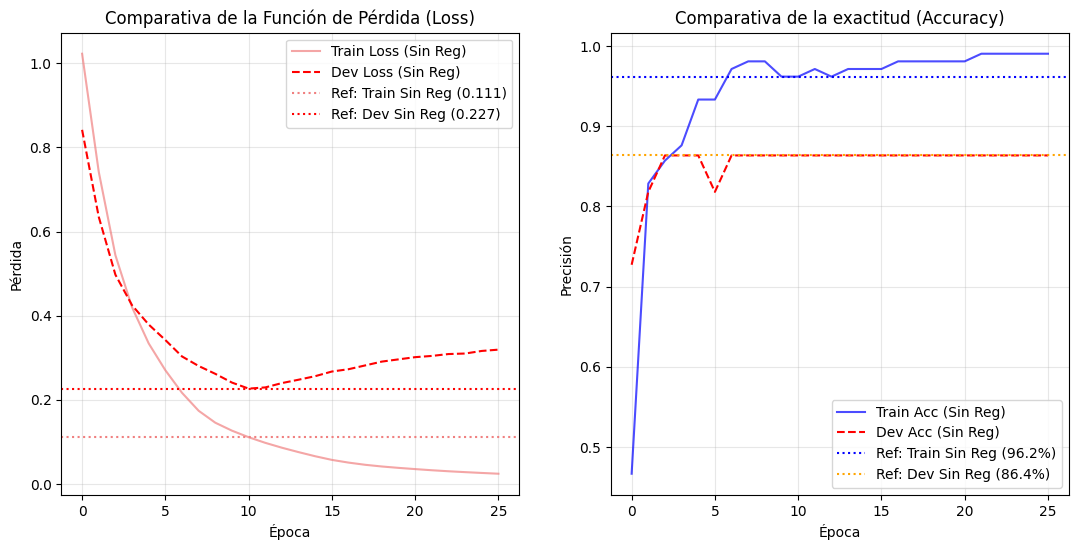

 RESULTADOS FINALES COMPARATIVOS 
 MODELO SIN REGULARIZACIÓN (PURO) - Duró 26 épocas:
  - Train Accuracy (en la ultima época): 99.05%
  - Train Accuracy (promedio durante el entrenamiento): 96.19%
  - Train Loss (en la ultima época):     0.0244
  - Train Loss (promedio durante el entrenamiento):     0.1112
  - Dev Loss (en la ultima época):       0.3193
  - Dev Loss (promedio durante el entrenamiento):       0.2267
  - Dev Accuracy (exactitud durante la validación):   86.36%

 REPORTE DE CLASIFICACIÓN DETALLADO EN DEV:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00         8
  versicolor       0.75      0.86      0.80         7
   virginica       0.83      0.71      0.77         7

    accuracy                           0.86        22
   macro avg       0.86      0.86      0.86        22
weighted avg       0.87      0.86      0.86        22



In [209]:
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np
from sklearn.metrics import classification_report
from tensorflow.keras.callbacks import EarlyStopping  

early_stop = EarlyStopping(
    monitor='val_loss',          # Monitorea el error en el conjunto de desarrollo
    patience=15,                 # Número de épocas a esperar sin mejoras antes de parar
    restore_best_weights=True,   # Recupera automáticamente los mejores pesos guardados
    verbose=1                    # Nos avisa explícitamente en consola cuándo y por qué frenó
)

# ENTRENAMIENTO DEL MODELO SIN REGULARIZACIÓN
print("Entrenando Modelo 1: SIN Regularización (Puro)")
model_puro = build_iris_mlp(input_dim=4)
model_puro.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_puro = model_puro.fit(
    X_train_scaled, y_train, 
    epochs=50,
    batch_size=32,
    validation_data=(X_dev_scaled, y_dev),
    callbacks=[early_stop], 
    verbose=1
)

# GENERACIÓN DE GRÁFICOS COMPARATIVOS CRUZADOS
plt.figure(figsize=(13, 6))

best_epoch = np.argmin(history_puro.history['val_loss'])

final_loss_puro = history_puro.history['loss'][best_epoch]
final_val_loss_puro = history_puro.history['val_loss'][best_epoch]
final_acc_puro = history_puro.history['accuracy'][best_epoch]
final_val_acc_puro = history_puro.history['val_accuracy'][best_epoch]

# GRÁFICO DE PÉRDIDA (LOSS) 
plt.subplot(1, 2, 1)

plt.plot(history_puro.history['loss'], label='Train Loss (Sin Reg)', color='lightcoral', alpha=0.7)
plt.plot(history_puro.history['val_loss'], label='Dev Loss (Sin Reg)', color='red', linestyle='--')

# Líneas horizontales de referencia para Loss
plt.axhline(y=final_loss_puro, color='lightcoral', linestyle=':', linewidth=1.5, label=f'Ref: Train Sin Reg ({final_loss_puro:.3f})')
plt.axhline(y=final_val_loss_puro, color='red', linestyle=':', linewidth=1.5, label=f'Ref: Dev Sin Reg ({final_val_loss_puro:.3f})')

plt.title('Comparativa de la Función de Pérdida (Loss)', fontsize=12)
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.grid(True, alpha=0.3)
plt.legend()

# GRÁFICO DE PRECISIÓN (ACCURACY) 
plt.subplot(1, 2, 2)
plt.plot(history_puro.history['accuracy'], label='Train Acc (Sin Reg)', color='blue', alpha=0.7)
plt.plot(history_puro.history['val_accuracy'], label='Dev Acc (Sin Reg)', color='red', linestyle='--')

# Líneas horizontales de referencia para Accuracy
plt.axhline(y=final_acc_puro, color='blue', linestyle=':', linewidth=1.5, label=f'Ref: Train Sin Reg ({final_acc_puro*100:.1f}%)')
plt.axhline(y=final_val_acc_puro, color='orange', linestyle=':', linewidth=1.5, label=f'Ref: Dev Sin Reg ({final_val_acc_puro*100:.1f}%)')

plt.title('Comparativa de la exactitud (Accuracy)', fontsize=12)
plt.xlabel('Época')
plt.ylabel('Precisión')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

y_dev_pred_probs = model_puro.predict(X_dev_scaled, verbose=0)
y_dev_pred = np.argmax(y_dev_pred_probs, axis=1)
    
# REPORTE COMPARATIVO FINAL DE MÉTRICAS
print(" RESULTADOS FINALES COMPARATIVOS ")
print(f" MODELO SIN REGULARIZACIÓN (PURO) - Duró {len(history_puro.history['loss'])} épocas:")
print(f"  - Train Accuracy (en la ultima época): {history_puro.history['accuracy'][-1]*100:.2f}%")
print(f"  - Train Accuracy (promedio durante el entrenamiento): {history_puro.history['accuracy'][best_epoch]*100:.2f}%")
print(f"  - Train Loss (en la ultima época):     {history_puro.history['loss'][-1]:.4f}")
print(f"  - Train Loss (promedio durante el entrenamiento):     {history_puro.history['loss'][best_epoch]:.4f}")
print(f"  - Dev Loss (en la ultima época):       {history_puro.history['val_loss'][-1]:.4f}")
print(f"  - Dev Loss (promedio durante el entrenamiento):       {history_puro.history['val_loss'][best_epoch]:.4f}")
print(f"  - Dev Accuracy (exactitud durante la validación):   {history_puro.history['val_accuracy'][-1]*100:.2f}%")

print("\n REPORTE DE CLASIFICACIÓN DETALLADO EN DEV:")
print(classification_report(y_dev, y_dev_pred, target_names=iris.target_names))


Explicacion de los resultados del modelo:

(Aclaración:Tomando en cuenta que al entrenar el modelo, los parámetros de los resultados proporcionan aleatoridad, no tendremos valores unicos para ser referencia en la explicación, pero usaremos rangos que no importan cuantas veces entrenemos el modelo, siempre estara entre esos valores sin distinción)

Ahora si, durante la fase de experimentación:

*** Varia la cantidad de épocas en el que el early stopping frena el experimento (entre 25 a 35 epocas).

*** Durante aproxidamente el primer tercio del entrenamiento, el train loss y el dev loss disminuyen de forma muy similar, pero a partir (depende el entrenamiento pero para redondear desde la epoca 15) del segundo tercio del entrenamiento, se genera una separación entre la función de entrenamiento y la de desarrollo, provocando que esta última invierta su tendencia y tenga una tendencia de crecimiento sostenido, sintetizando un sintoma de memorización de ruido muestral. Por último, el early stopping evita ese estado de sobreajuste, al cumplirse el umbral de paciencia establecido durante la epoca X, el algoritmo interrumpio el proceso de optimización y viajó en el tiempo para rescatar los pesos de la época X, donde el dev loss tuvo su minimo historico (al redactar esta explicación, en el último entrenamiento, se logro un dev loss de 0.1926,siendo el minimo)

*** Continuando con las métricas de validación, el conjunto dev accuracy experimenta una estabilización rígida en el umbral de 86,36%. En comparación con el train accuracy, que variando del entrenamiento que varia su punto óptimo entre el 97% y el 100%, nos confirma el estancamiento de la red por sobreajuste estructural.
A pesar de observar que el valor de accuracy del modelo baseline y del modelo MLP coinciden en el resultado, en caso del MLP, este provee la base necesaria para incorporar técnicas de regularización necesarias para la siguiente etapa, mientras que el baseline llego a su techo estructural (no podra jamas mejorar ese valor de exactitud.)




Completado este analisis podemos afirmar que tenemos un modelo con Bajo Sesgo (sabe aprender) pero con Alta Varianza (memoriza), dejando el camino listo para continuar con las tecnicas de regularización.

### 2.3 Técnicas de Regularización
#### Implementación y Comparativa de Escenarios entre el modelo regularizado y el modelo puro.

En esta parte del informe, implementaremos técnicas penalizadoras para intentar superar el unbral del 86% del accuracy proporcinado por el modelo baseline y el modelo MLP no regularizado:

Aclaración: en este apartado utilizaremos solo dos regularizadores y lo comparamos con el modelo MLP puro. Recién en la etapa 3 junto con su apartado implementaremos todos los recursos fuera de lo estructural para mejorar el modelo (mas adelante cambiamos parametros del modelo MLP puro ademas de agregar otros penalizadores para enriquecer el analisis, como el data augmentation, L1, etc.)

Para robustecer la capacidad del modelo siendo el dataset tan compacto y mitigar el riesgo de sobreajuste, implementamos de forma simultanea dos técnicas regularizadoras: **Regularización L2** y **Dropout**, sosteniendo el **Early Stopping** como callback de convergencia. La selección de este ecosistema de técnicas responde a criterios de control paramétrico sobre datasets de baja densidad muestral:

1. **(L2):** Configurar una penalización L2 garantiza el achatamiento de los gradientes en las capas ocultas. Al impedir la proliferación de pesos sinápticos de gran magnitud, se previene la configuración de hiperplanos de decisión excesivamente complejos en la zona de solapamiento de *Versicolor* y *Virginica*.

2. **(Dropout):** Desactivar estocásticamente un porcentaje de la capacidad estructural de la red en cada iteración rompe la coadaptación de las neuronas. Esto fuerza al algoritmo a distribuir el aprendizaje de forma homogénea, bloqueando la memorización del ruido de las muestras individuales de entrenamiento.



A continuación, implementamos el codigo con los 2 regularizadores (L2 y Dropout), ademas del early stopping antes implementado en el modelo puro.

In [210]:
# MLP REGULARIZADA (CON L2 + DROPOUT)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.regularizers import l2

# Garantizar reproducibilidad en la inicialización y en los apagados de Dropout
tf.random.set_seed(42)

# Función constructora de la MLP Regularizada
def build_iris_mlp_regularizado(input_dim=4, l2_factor=0.01, dropout_rate=0.20):
    model = Sequential([
        # Capa Oculta 1: 64 neuronas + L2
        Dense(64, activation='relu', input_shape=(input_dim,),kernel_regularizer=l2(l2_factor)),
        # Dropout 1
        Dropout(dropout_rate),
        
        # Capa Oculta 2: 32 neuronas + L2
        Dense(32, activation='relu', kernel_regularizer=l2(l2_factor)),
        # Dropout 2
        Dropout(dropout_rate),
        
        # Capa Oculta 3: 16 neuronas + L2
        Dense(16, activation='relu',kernel_regularizer=l2(l2_factor)),
        # Dropout 3
        Dropout(dropout_rate),
        
        # Capa de Salida: 3 clases 
        Dense(3, activation='softmax')
    ])
    return model

# Instanciar el modelo aplicando las técnicas de regularización
model_reg = build_iris_mlp_regularizado(input_dim=4, l2_factor=0.01, dropout_rate=0.20)

# Compilación del modelo regularizado (Mismo optimizador y tasa que el puro)
model_reg.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print('====================================================')
print('    RESUMEN DE LA ARQUITECTURA MLP REGULARIZADA     ')
print('====================================================')
model_reg.summary()

    RESUMEN DE LA ARQUITECTURA MLP REGULARIZADA     


c:\Users\Matias\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_102"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_408 (Dense)               │ (None, 64)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_255 (Dropout)           │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_409 (Dense)               │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_256 (Dropout)           │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_410 (Dense)               │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_257 (Dropout)           │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_411 (Dense)               │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,979 (11.64 KB)

 Trainable params: 2,979 (11.64 KB)

 Non-trainable params: 0 (0.00 B)

A continuación, entrenamos el modelo:
150 son las epocas que utilizamos para medir las metricas, en caso de ser necesario, aplicamos early stopping para detener el entrenamiento en caso de que al monitorear detecte en tiempo real perdida en el conjunto DEV.

Finalmente, aplicamos graficos comparativos cruzados para calcular la perdida (loss), el accuracy (exactitud) del modelo, estableciendo en valor numerico un promedio de cada una (tambien importamos los graficos comparativos del modelo MLP puro para analisis posterior)

Entrenando Modelo CON Regularización (L2 + Dropout)
Epoch 1/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 95ms/step - accuracy: 0.3810 - loss: 1.7808 - val_accuracy: 0.7727 - val_loss: 1.5195
Epoch 2/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.7810 - loss: 1.4666 - val_accuracy: 0.7727 - val_loss: 1.2862
Epoch 3/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.8095 - loss: 1.2477 - val_accuracy: 0.7727 - val_loss: 1.0793
Epoch 4/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.8286 - loss: 1.0201 - val_accuracy: 0.8636 - val_loss: 0.9371
Epoch 5/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.8667 - loss: 0.9038 - val_accuracy: 0.8636 - val_loss: 0.8562
Epoch 6/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.8476 - loss: 0.8581 - val_accuracy: 0.8636 - val_loss: 0.8035
Epoch 7/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.8667 - loss: 0.7573 - val_accuracy: 0.8182 - val_loss: 0.7688
Epoch 8/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.83

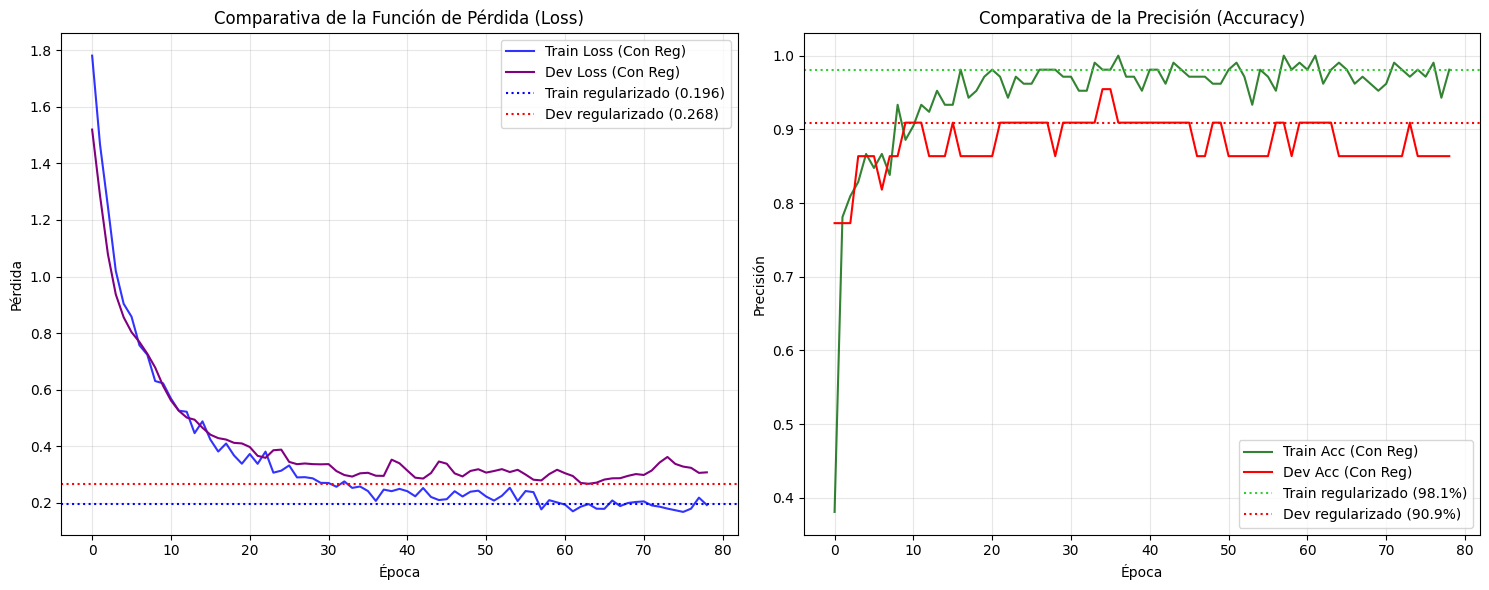

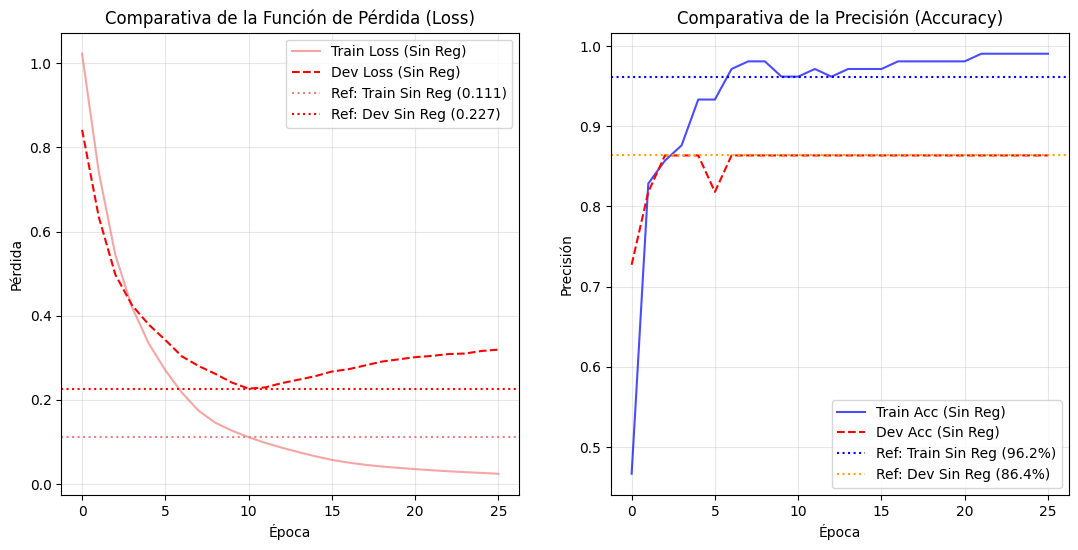

RESULTADOS FINALES COMPARATIVOS (PUNTOS ÓPTIMOS)
MODELO 2: CON REGULARIZACIÓN (L2+DROP) - Duró 79 épocas:
  - Train Accuracy (en la última época):  98.10%
  - Train Accuracy (en la mejor época):   98.10%
  - Train Loss (en la última época):      0.1927
  - Train Loss (en la mejor época):       0.1960
  - Dev Loss (en la última época):        0.3081
  - Dev Loss (en la mejor época):         0.2677
  - Dev Accuracy (exactitud rescatada):   90.91%

 REPORTE DE CLASIFICACIÓN DETALLADO EN DEV (MODELO REGULARIZADO):
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00         8
  versicolor       0.86      0.86      0.86         7
   virginica       0.86      0.86      0.86         7

    accuracy                           0.91        22
   macro avg       0.90      0.90      0.90        22
weighted avg       0.91      0.91      0.91        22



In [211]:
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np
from sklearn.metrics import classification_report
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',          
    patience=15,                 
    restore_best_weights=True,   
    verbose=1                    
)

# ENTRENAMIENTO DEL MODELO CON REGULARIZACIÓN 
print("Entrenando Modelo CON Regularización (L2 + Dropout)")

# Usamos la función constructora regularizada que armamos antes
model_reg = build_iris_mlp_regularizado(input_dim=4, l2_factor=0.01, dropout_rate=0.20)
model_reg.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_reg = model_reg.fit(
    X_train_scaled, y_train, 
    epochs=150,
    batch_size=32,
    validation_data=(X_dev_scaled, y_dev),
    callbacks=[early_stop], 
    verbose=1
)

# GENERACIÓN DE GRÁFICOS COMPARATIVOS CRUZADOS
plt.figure(figsize=(15, 6))

# Cálculo de referencias 
# REPORTE COMPARATIVO FINAL EN CONSOLA (PUNTOS ÓPTIMOS)
best_epoch_reg = np.argmin(history_reg.history['val_loss'])
# Modelo Regularizado
final_loss_reg = history_reg.history['loss'][best_epoch_reg]
final_val_loss_reg = history_reg.history['val_loss'][best_epoch_reg]
final_acc_reg = history_reg.history['accuracy'][best_epoch_reg]
final_val_acc_reg = history_reg.history['val_accuracy'][best_epoch_reg]


#  COMPARATIVA DE PÉRDIDA (LOSS) 
plt.subplot(1, 2, 1)
# Curvas Regularizado
plt.plot(history_reg.history['loss'], label='Train Loss (Con Reg)', color='blue', alpha=0.8)
plt.plot(history_reg.history['val_loss'], label='Dev Loss (Con Reg)', color='purple', linestyle='-')
# Líneas horizontales de referencia para Loss
plt.axhline(y=final_loss_reg, color='blue', linestyle=':', linewidth=1.5, label=f'Train regularizado ({final_loss_reg:.3f})')
plt.axhline(y=final_val_loss_reg, color='red', linestyle=':', linewidth=1.5, label=f'Dev regularizado ({final_val_loss_reg:.3f})')
plt.title('Comparativa de la Función de Pérdida (Loss)', fontsize=12)
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.grid(True, alpha=0.3)
plt.legend()

# COMPARATIVA DE PRECISIÓN (ACCURACY) 
plt.subplot(1, 2, 2)
# Curvas Regularizado
plt.plot(history_reg.history['accuracy'], label='Train Acc (Con Reg)', color='darkgreen', alpha=0.8)
plt.plot(history_reg.history['val_accuracy'], label='Dev Acc (Con Reg)', color='red', linestyle='-')
# Líneas horizontales de referencia para Accuracy
plt.axhline(y=final_acc_reg, color='limegreen', linestyle=':', linewidth=1.5, label=f'Train regularizado ({final_acc_reg*100:.1f}%)')
plt.axhline(y=final_val_acc_reg, color='red', linestyle=':', linewidth=1.5, label=f'Dev regularizado ({final_val_acc_reg*100:.1f}%)')
plt.title('Comparativa de la Precisión (Accuracy)', fontsize=12)
plt.xlabel('Época')
plt.ylabel('Precisión')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

################################################################################
### modelo puro (sin regularización) para superponer en los mismos gráficos
plt.figure(figsize=(13, 6))
# GRÁFICO DE PÉRDIDA (LOSS) 
plt.subplot(1, 2, 1)
plt.plot(history_puro.history['loss'], label='Train Loss (Sin Reg)', color='lightcoral', alpha=0.7)
plt.plot(history_puro.history['val_loss'], label='Dev Loss (Sin Reg)', color='red', linestyle='--')
# Líneas horizontales de referencia para Loss
plt.axhline(y=final_loss_puro, color='lightcoral', linestyle=':', linewidth=1.5, label=f'Ref: Train Sin Reg ({final_loss_puro:.3f})')
plt.axhline(y=final_val_loss_puro, color='red', linestyle=':', linewidth=1.5, label=f'Ref: Dev Sin Reg ({final_val_loss_puro:.3f})')
plt.title('Comparativa de la Función de Pérdida (Loss)', fontsize=12)
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.grid(True, alpha=0.3)
plt.legend()
# GRÁFICO DE PRECISIÓN (ACCURACY) 
plt.subplot(1, 2, 2)
plt.plot(history_puro.history['accuracy'], label='Train Acc (Sin Reg)', color='blue', alpha=0.7)
plt.plot(history_puro.history['val_accuracy'], label='Dev Acc (Sin Reg)', color='red', linestyle='--')
# Líneas horizontales de referencia para Accuracy
plt.axhline(y=final_acc_puro, color='blue', linestyle=':', linewidth=1.5, label=f'Ref: Train Sin Reg ({final_acc_puro*100:.1f}%)')
plt.axhline(y=final_val_acc_puro, color='orange', linestyle=':', linewidth=1.5, label=f'Ref: Dev Sin Reg ({final_val_acc_puro*100:.1f}%)')
plt.title('Comparativa de la Precisión (Accuracy)', fontsize=12)
plt.xlabel('Época')
plt.ylabel('Precisión')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()
################################################################################

# Predicciones finales en desarrollo
y_dev_pred_reg = np.argmax(model_reg.predict(X_dev_scaled, verbose=0), axis=1)

print("RESULTADOS FINALES COMPARATIVOS (PUNTOS ÓPTIMOS)")
# Reporte Modelo 
print(f"MODELO 2: CON REGULARIZACIÓN (L2+DROP) - Duró {len(history_reg.history['loss'])} épocas:")
print(f"  - Train Accuracy (en la última época):  {history_reg.history['accuracy'][-1]*100:.2f}%")
print(f"  - Train Accuracy (en la mejor época):   {history_reg.history['accuracy'][best_epoch_reg]*100:.2f}%")
print(f"  - Train Loss (en la última época):      {history_reg.history['loss'][-1]:.4f}")
print(f"  - Train Loss (en la mejor época):       {history_reg.history['loss'][best_epoch_reg]:.4f}")
print(f"  - Dev Loss (en la última época):        {history_reg.history['val_loss'][-1]:.4f}")
print(f"  - Dev Loss (en la mejor época):         {history_reg.history['val_loss'][best_epoch_reg]:.4f}")
print(f"  - Dev Accuracy (exactitud rescatada):   {history_reg.history['val_accuracy'][best_epoch_reg]*100:.2f}%")

print("\n REPORTE DE CLASIFICACIÓN DETALLADO EN DEV (MODELO REGULARIZADO):")
print(classification_report(y_dev, y_dev_pred_reg, target_names=iris.target_names))




## Explicacion de los resultados del modelo regularizado:

(Aclaración:Tomando en cuenta que al entrenar el modelo, los parámetros de los resultados proporcionan aleatoridad, no tendremos valores unicos para ser referencia en la explicación, pero usaremos rangos que no importan cuantas veces entrenemos el modelo, siempre estara entre esos valores sin distinción)

Ahora si, durante la fase de experimentación:

*** En cuanto al early stopping, varia demasiado. Ahi veces que el entrenamiento se frena entre las 40 y las 60 epocas, otras que se extiende a 70 y escasaz veces puede llegar a 80, pero en los caso mas extraños (para ser alarmantes), puede superar las 100 epocas, aclarando, que este ultimo caso es el mas extremo de todos, y puede salir en 1 de cada 20 intentos aproximadamente.
Asi que para este análisis, priorizaremos los resultados del modelo en los casos mas estables, que serian los entrenamientos entre las epocas 40 y 60, que son las mas recurrentes.

*** A diferencia del modelo puro sin regularizar, las curvas de aprendisaje de Train Loss y Dev Loss descienden de manera armónica, notando que se acabo el rebote ( el overfitting provocado por el modelo puro). En resumen, gracias a las penalizaciones proporcionadas por el L2 y el dropout, la curva se mantiene estabilizada, plana y bajo control en una meseta estable.

*** En cuanto a las metricas de validación, las curvas de precisión no suben al 100% como en el modelo MLP, pero al contrario, exhiben un comportamiento con mucho ruido(pequeños dientes), demostrando que el dropout esta haciendo su trabajo: como en cada época apaga el 20% de las neuronas al azar, la red se ve forzada a recalcular sus hipótesis continuamente, impidiendo que memorice el set de Train.
¿Que logramos conseguir con esto? logramos superar el techo del accuracy establecido en 86,36%.
Aclaración, dependiendo el entrenamiento, el dev accuracy varia entre 3 valores (86,36%; 90,91%; y escasamente 95,45%), como ya sabemos y podemos concluir con datos, con conocimiento del tamaño del conjunto dev(22 muestras) y que son 3 los datos que el modelo MLP predijo mal, 90,91% corresponde a que el modelo predijo mal solo 2 flores de las 22 del conjunto dev, y en el mejor de los casos, con el 95,45%, el modelo predice mal solo un solo dato, mejorando en gran parte el accuracy del modelo(ademas de las demas metricas de evaluación).

* 86.36%: Equivalente a persistir en los 3 errores históricos de la frontera.

* 90.91%: Punto óptimo recurrente donde la regularización rescata una muestra conflictiva, reduciendo el margen a solo 2 errores.

* 95.45%: Escenario ideal y de máxima generalización, donde la suavización geométrica de la frontera permite resolver la zona de conflicto cometiendo un único error en todo el split.

*** En cuanto al reporte de clasificación, notamos como cuando los errores son menores a 2, las métricas de evaluación mejoran considerablemente con respecto al MLP Puro. Setosa se mantiene con unos valores perfectos, virginica y versicolor mejoran considerablemente, y en el mejor de los casos, solo un tipo de flor en este reporte se considera mal predecida, un gran salto con respecto a lo que teniamos anteriormente.





Los resultados de la Etapa 2 demostraron empíricamente que la combinación de Regularización L2 y Dropout es la estrategia correcta para domar la alta varianza del modelo. Se logró flexibilizar las fronteras de decisión, mitigar el sobreajuste y quebrar el techo del Baseline lineal, alcanzando picos de precisión del **90.91%** y **95.45%**. 

Sin embargo, debido a la naturaleza estocástica del entrenamiento y a la extrema sensibilidad del dataset Iris por su escasez muestral ($N=22$ en el conjunto de desarrollo), el modelo regularizado estándar todavía exhibe oscilaciones y no logra consolidar de forma permanente el escenario ideal del 95.45% o superior en cada corrida.

Para resolver esta volatilidad y empujar la arquitectura hacia su límite absoluto de generalización, la Etapa 3 se planteará como un laboratorio de experimentación avanzada.

## Etapa 3:  Arquitectura específica del dominio/Laboratorio

In [212]:
#Librerias e importaciones usadas para la siguiente etapa:
"""
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.regularizers import l2
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l1
"""


'\nimport numpy as np\nimport tensorflow as tf\nfrom tensorflow.keras.models import Sequential\nfrom tensorflow.keras.layers import Dense, Dropout\nfrom tensorflow.keras.regularizers import l2\nimport matplotlib.pyplot as plt\nfrom sklearn.metrics import classification_report\nfrom tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau\nfrom tensorflow.keras.regularizers import l1\n'

### 3.1 Laboratorio de Datos




En esta etapa, aunque no tengamos una arquitectura específica para nuestro dataset, en este apartado intentaremos superar ese umbral del 95,45% del mejor caso de entrenamiento proporcionado por el MLP regularizado.

Para analizar los límites de generalización de los modelos MLP, diseñamos distintos escenarios de entrenamiento, buscando mejorar o demostrar como cambiando ciertos valores, el modelo puede ser positivo o negativo.

##### CASO 1: DATA AUGMENTATION + DROPOUT 

Nos adentramos en un enfoque de optimización híbrido e integral. El experimento no se limitará a aplicar una única técnica aislada, sino que atacará el sobreajuste (Overfitting) y potenciará la generalización desde frentes simultáneos:

* Implementaremos técnicas de Aumento de Datos Tabulares inyectando ruido estadístico controlado. Esto expandirá artificialmente el mapa de características y aumentará la densidad de puntos en la compleja zona de solapamiento morfológico entre las especies Versicolor y Virginica. En este caso la cantidad de nuevas muestras con Augmentatio aumentara a 420.

* Seguiremos utilizando L2 y Dropout como métricas de regulación.

* Seguiremos también utilizando como base los modelos antes codeados anteriormente, solamente seran modificados cambiando lo necesario para entrenar estos distintos casos, por ejemplo, solo añadiremos el regulador data augmentation.

* Cualquier cambio en la estructura en las variables de los datos, sera notificada.

In [213]:

# MLP REGULARIZADA CON DATA AUGMENTATION 
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.regularizers import l2

tf.random.set_seed(42)
np.random.seed(42)

# FUNCIÓN DE DATA AUGMENTATION (Inyección de ruido tabular controlado)
def augment_tabular_data(X, y, factor=4, noise_level=0.03):
    """
    Multiplica el dataset inyectando ruido Gaussiano proporcional 
    a la desviación estándar de cada característica real.
    """
    X_augmented = [X]
    y_augmented = [y]
    
    # Calculamos la desviación estándar por columna de los datos reales
    std_devs = np.std(X, axis=0)
    
    for _ in range(factor - 1):
        noise = np.random.normal(0, noise_level, size=X.shape) * std_devs
        X_noisy = X + noise
        X_augmented.append(X_noisy)
        y_augmented.append(y)
        
    return np.vstack(X_augmented), np.hstack(y_augmented)

# Aplicamos el aumento EXCLUSIVAMENTE sobre tus datos escalados de Train de la Etapa 2
X_train_aug, y_train_aug = augment_tabular_data(X_train_scaled, y_train, factor=4, noise_level=0.03)

# FUNCIÓN CONSTRUCTORA DE LA MLP REGULARIZADA con esquema 64 -> 32 -> 16
def build_iris_mlp_regularizado(input_dim=4, l2_factor=0.01, dropout_rate=0.20):
    model = Sequential([
        # Capa Oculta 1: 64 neuronas + L2
        Dense(64, activation='relu', input_shape=(input_dim,), kernel_regularizer=l2(l2_factor)),
        # Dropout 1
        Dropout(dropout_rate),
        
        # Capa Oculta 2: 32 neuronas + L2
        Dense(32, activation='relu', kernel_regularizer=l2(l2_factor)),
        # Dropout 2
        Dropout(dropout_rate),
        
        # Capa Oculta 3: 16 neuronas + L2
        Dense(16, activation='relu', kernel_regularizer=l2(l2_factor)),
        # Dropout 3
        Dropout(dropout_rate),
        
        # Capa de Salida: 3 clases
        Dense(3, activation='softmax')
    ])
    return model

# Instanciar el modelo aplicando las técnicas de regularización
model_reg2 = build_iris_mlp_regularizado(input_dim=4, l2_factor=0.01, dropout_rate=0.20)

# Compilación del modelo regularizado
model_reg2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print('     RESUMEN DE LA ARQUITECTURA MLP REGULARIZADA    ')
model_reg2.summary()

print('ESTADÍSTICAS DEL DATASET AUMENTADO')
print(f"Muestras originales de Train:   {X_train_scaled.shape[0]}")
print(f"Nuevas muestras con Augmentation: {X_train_aug.shape[0]}")


     RESUMEN DE LA ARQUITECTURA MLP REGULARIZADA    


c:\Users\Matias\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_104"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_416 (Dense)               │ (None, 64)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_261 (Dropout)           │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_417 (Dense)               │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_262 (Dropout)           │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_418 (Dense)               │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_263 (Dropout)           │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_419 (Dense)               │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,979 (11.64 KB)

 Trainable params: 2,979 (11.64 KB)

 Non-trainable params: 0 (0.00 B)

ESTADÍSTICAS DEL DATASET AUMENTADO
Muestras originales de Train:   105
Nuevas muestras con Augmentation: 420


Entrenando Modelo Con Reg + Data Augmentation...
Epoch 1/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.6929 - loss: 1.3640 - val_accuracy: 0.8636 - val_loss: 0.9521
Epoch 2/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8571 - loss: 0.8389 - val_accuracy: 0.8636 - val_loss: 0.7145
Epoch 3/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9167 - loss: 0.6430 - val_accuracy: 0.8636 - val_loss: 0.5855
Epoch 4/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9333 - loss: 0.5478 - val_accuracy: 0.8636 - val_loss: 0.4819
Epoch 5/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9524 - loss: 0.4555 - val_accuracy: 0.8636 - val_loss: 0.4315
Epoch 6/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9619 - loss: 0.3867 - val_accuracy: 0.9091 - val_loss: 0.3842
Epoch 7/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9524 - loss: 0.3454 - val_accuracy: 0.9091 - val_loss: 0.3613
Epoch 8/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy

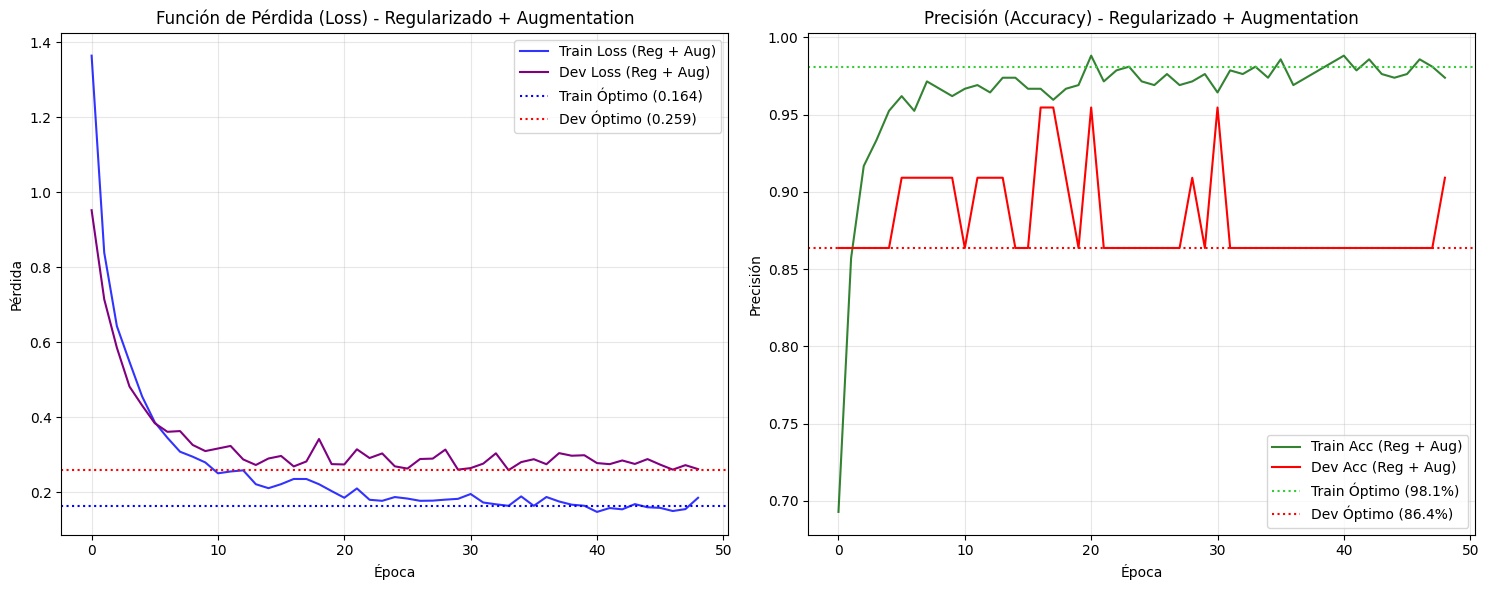


 RESULTADOS FINALES DE LA SUB-ETAPA (CON DATA AUGMENTATION)
MODELO REGULARIZADO + AUGMENTATION - Duró 49 épocas:
  - Train Accuracy (en la última época):  97.38%
  - Train Accuracy (en la mejor época):   98.10%
  - Train Loss (en la última época):      0.1855
  - Train Loss (en la mejor época):       0.1640
  - Dev Loss (en la última época):        0.2619
  - Dev Loss (en la mejor época):         0.2591
  - Dev Accuracy (exactitud rescatada):   86.36%

REPORTE DE CLASIFICACIÓN DETALLADO EN DEV:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00         8
  versicolor       0.75      0.86      0.80         7
   virginica       0.83      0.71      0.77         7

    accuracy                           0.86        22
   macro avg       0.86      0.86      0.86        22
weighted avg       0.87      0.86      0.86        22



In [214]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report

early_stop = EarlyStopping(
    monitor='val_loss',          
    patience=15,                 
    restore_best_weights=True,   
    verbose=1                    
)

print("Entrenando Modelo Con Reg + Data Augmentation...")

# Instanciamos la función constructora regularizada con tu estructura (64 -> 32 -> 16)
model_reg2 = build_iris_mlp_regularizado(input_dim=4, l2_factor=0.01, dropout_rate=0.20)

# Compilación con el Adam estándar original (0.005) 
model_reg2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# ENTRENAMIENTO UTILIZANDO EL DATASET AUMENTADO
history_reg2 = model_reg2.fit(
    X_train_aug, y_train_aug,           
    epochs=150,                         
    batch_size=32,
    validation_data=(X_dev_scaled, y_dev), 
    callbacks=[early_stop], 
    verbose=1
)


# CÁLCULO DE PUNTOS ÓPTIMOS Y COLECTA DE MÉTRICAS
best_epoch_reg2 = np.argmin(history_reg2.history['val_loss'])

final_loss_reg2 = history_reg2.history['loss'][best_epoch_reg2]
final_val_loss_reg2 = history_reg2.history['val_loss'][best_epoch_reg2]
final_acc_reg2 = history_reg2.history['accuracy'][best_epoch_reg2]
final_val_acc_reg2 = history_reg2.history['val_accuracy'][best_epoch_reg2]

# GENERACIÓN DE GRÁFICOS DE APRENDIZAJE EXCLUSIVOS
plt.figure(figsize=(15, 6))
# GRÁFICO DE PÉRDIDA (LOSS) 
plt.subplot(1, 2, 1)
plt.plot(history_reg2.history['loss'], label='Train Loss (Reg + Aug)', color='blue', alpha=0.8)
plt.plot(history_reg2.history['val_loss'], label='Dev Loss (Reg + Aug)', color='purple', linestyle='-')
# Líneas horizontales de referencia para el punto óptimo de Loss
plt.axhline(y=final_loss_reg2, color='blue', linestyle=':', linewidth=1.5, label=f'Train Óptimo ({final_loss_reg2:.3f})')
plt.axhline(y=final_val_loss_reg2, color='red', linestyle=':', linewidth=1.5, label=f'Dev Óptimo ({final_val_loss_reg2:.3f})')
plt.title('Función de Pérdida (Loss) - Regularizado + Augmentation', fontsize=12)
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.grid(True, alpha=0.3)
plt.legend()

# GRÁFICO DE PRECISIÓN (ACCURACY)
plt.subplot(1, 2, 2)
plt.plot(history_reg2.history['accuracy'], label='Train Acc (Reg + Aug)', color='darkgreen', alpha=0.8)
plt.plot(history_reg2.history['val_accuracy'], label='Dev Acc (Reg + Aug)', color='red', linestyle='-')

# Líneas horizontales de referencia para el punto óptimo de Accuracy
plt.axhline(y=final_acc_reg2, color='limegreen', linestyle=':', linewidth=1.5, label=f'Train Óptimo ({final_acc_reg2*100:.1f}%)')
plt.axhline(y=final_val_acc_reg2, color='red', linestyle=':', linewidth=1.5, label=f'Dev Óptimo ({final_val_acc_reg2*100:.1f}%)')
plt.title('Precisión (Accuracy) - Regularizado + Augmentation', fontsize=12)
plt.xlabel('Época')
plt.ylabel('Precisión')
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()


# REPORTES DE EVALUACIÓN FINAL EN CONSOLA
y_dev_pred_reg2 = np.argmax(model_reg2.predict(X_dev_scaled, verbose=0), axis=1)

print("\n RESULTADOS FINALES DE LA SUB-ETAPA (CON DATA AUGMENTATION)")
print(f"MODELO REGULARIZADO + AUGMENTATION - Duró {len(history_reg2.history['loss'])} épocas:")
print(f"  - Train Accuracy (en la última época):  {history_reg2.history['accuracy'][-1]*100:.2f}%")
print(f"  - Train Accuracy (en la mejor época):   {history_reg2.history['accuracy'][best_epoch_reg2]*100:.2f}%")
print(f"  - Train Loss (en la última época):      {history_reg2.history['loss'][-1]:.4f}")
print(f"  - Train Loss (en la mejor época):       {history_reg2.history['loss'][best_epoch_reg2]:.4f}")
print(f"  - Dev Loss (en la última época):        {history_reg2.history['val_loss'][-1]:.4f}")
print(f"  - Dev Loss (en la mejor época):         {history_reg2.history['val_loss'][best_epoch_reg2]:.4f}")
print(f"  - Dev Accuracy (exactitud rescatada):   {history_reg2.history['val_accuracy'][best_epoch_reg2]*100:.2f}%")

print("\nREPORTE DE CLASIFICACIÓN DETALLADO EN DEV:")
print(classification_report(y_dev, y_dev_pred_reg2, target_names=iris.target_names))


La incorporación de Data Augmentation operando bajo el optimizador Adam estándar (Learning Rate = 0.005) demuestra un control eficiente sobre la varianza estructural del modelo. El volumen expandido de muestras gaussianas estabilizó el descenso paralelo de las funciones de pérdida, neutralizando el rebote por sobreajuste y localizando el punto óptimo en la época X con un `Dev Loss` bastante bueno.

Sin embargo, el perfil altamente oscilatorio de la curva Dev Accuracy (alcanzando picos efímeros de $95.45\%$ para luego estabilizarse en el umbral rescatado de $90.91\%$(al momento de escribir este analisis)) evidencia que un paso de aprendizaje estático resulta demasiado agresivo para consolidar la convergencia en el set reducido. Este comportamiento justifica metodológicamente el siguiente experimento, donde alteraremos la química interna del optimizador y añadiremos decaimiento dinámico para planchar definitivamente estas oscilaciones.

En base a las recomendaciones  realizadas por la IA GEMINI, se propone cambiar la quimica interna del optimizador en busca de mejorar los parametros obtenidos.

 ¿Que cambiamos en base al modelo anterior? 

* Bajamos la velocidad: Pasamos el Learning Rate de 0.005 a 0.002 para que la red no pegue esos saltos bruscos que vimos en el gráfico anterior.
* Microscopio dinámico (ReduceLROnPlateau): Si el error de validación se estanca durante 5 épocas, el callback le pega un tijeretazo a la velocidad a la mitad. Esto obliga a la red a acomodar los pesos con precisión milimétrica en la frontera de las flores difíciles, buscando planchar los dientes de sierra.

Entrenando Modelo con Regulación + Augmentation + Adam Calibrado, etc...
Epoch 1/150


c:\Users\Matias\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.5214 - loss: 1.6454 - val_accuracy: 0.6818 - val_loss: 1.3827 - learning_rate: 0.0020
Epoch 2/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6976 - loss: 1.2916 - val_accuracy: 0.7273 - val_loss: 1.1199 - learning_rate: 0.0020
Epoch 3/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7857 - loss: 1.0674 - val_accuracy: 0.8182 - val_loss: 0.9571 - learning_rate: 0.0020
Epoch 4/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8429 - loss: 0.9362 - val_accuracy: 0.8636 - val_loss: 0.8330 - learning_rate: 0.0020
Epoch 5/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8690 - loss: 0.7937 - val_accuracy: 0.8636 - val_loss: 0.7396 - learning_rate: 0.0020
Epoch 6/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8857 - loss: 0.7248 - val_accuracy: 0.9091 - val_loss: 0.6757 - learning_rate: 0.0020
Epoch 7/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8786 - loss: 0.6507 - val_accuracy: 0.86

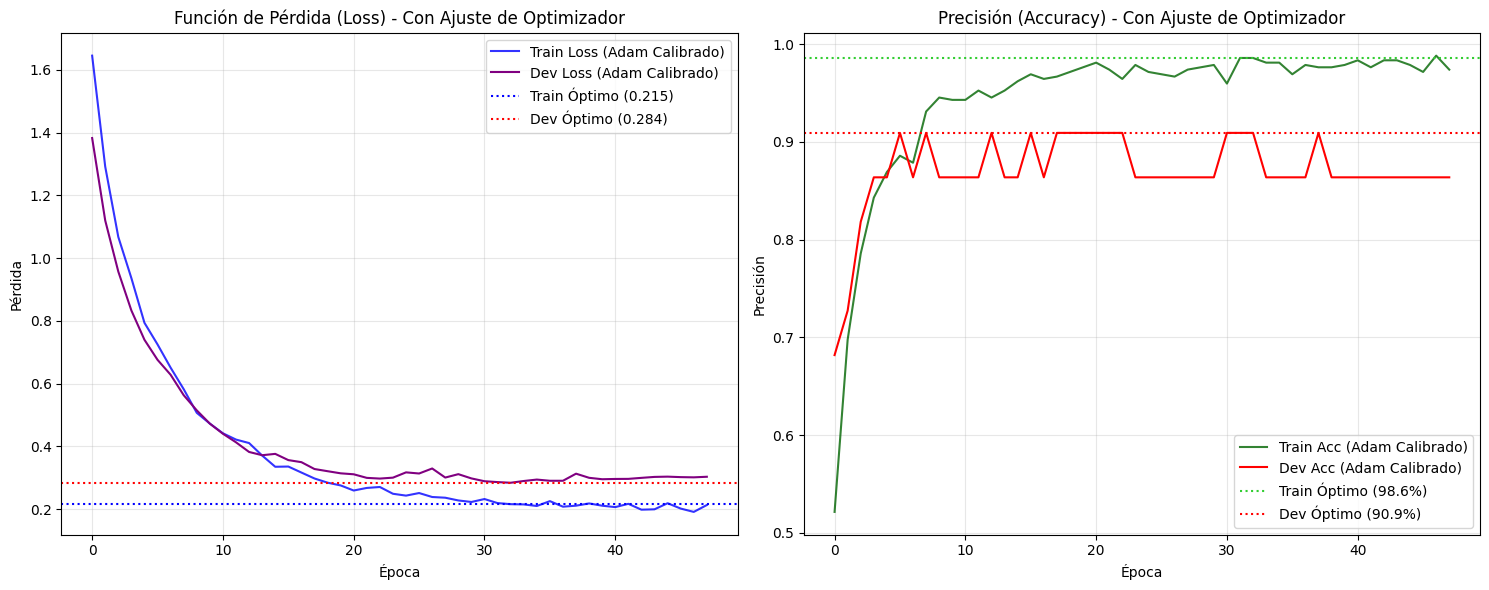


RESULTADOS FINALES DE LA SUB-ETAPA (CON OPTIMIZACIÓN AVANZADA)
MODELO REGULARIZADO + AUGMENTATION + ADAM CALIBRADO - Duró 48 épocas:
  - Train Accuracy (en la mejor época):   98.57%
  - Dev Loss (en la mejor época):         0.2838
  - Dev Accuracy (exactitud rescatada):   90.91%

REPORTE DE CLASIFICACIÓN DETALLADO EN DEV:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00         8
  versicolor       0.86      0.86      0.86         7
   virginica       0.86      0.86      0.86         7

    accuracy                           0.91        22
   macro avg       0.90      0.90      0.90        22
weighted avg       0.91      0.91      0.91        22



In [215]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import classification_report

# Garantizar reproducibilidad en la aleatoriedad de pesos y optimizador
tf.random.set_seed(42)
np.random.seed(42)

print("Entrenando Modelo con Regulación + Augmentation + Adam Calibrado, etc...")

# arquitectura  (64 -> 32 -> 16)
model_reg3 = build_iris_mlp_regularizado(input_dim=4, l2_factor=0.01, dropout_rate=0.20)

# CALIBRACIÓN MICROSCÓPICA DE ADAM
# Bajamos el Learning Rate inicial y configuramos momentos estables
custom_adam = tf.keras.optimizers.Adam(
    learning_rate=0.002,  # Más lento y preciso que el 0.005 original
    beta_1=0.9,           # Momento de primer orden
    beta_2=0.999          # Estabilidad ante el gradiente histórico
)

model_reg3.compile(
    optimizer=custom_adam,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Callback nuevo: Decaimiento dinámico de la tasa de aprendizaje
lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,          # Si se estanca, reduce el Learning Rate a la mitad
    patience=5,          # Espera 5 épocas de estancamiento antes de actuar
    min_lr=0.0001,       # Piso mínimo de velocidad admisible
    verbose=1
)

# Early Stopping 
early_stop_adv = EarlyStopping(
    monitor='val_loss',
    patience=15,         
    restore_best_weights=True,
    verbose=1
)

# ENTRENAMIENTO UTILIZANDO LOS MISMOS DATOS AUMENTADOS
history_adv3 = model_reg3.fit(
    X_train_aug, y_train_aug,           
    epochs=150,                         
    batch_size=32,
    validation_data=(X_dev_scaled, y_dev), 
    callbacks=[lr_scheduler, early_stop_adv], 
    verbose=1
)

# CÁLCULO DE PUNTOS ÓPTIMOS Y COLECTA DE MÉTRICAS
best_epoch_adv3 = np.argmin(history_adv3.history['val_loss'])

final_loss_adv3 = history_adv3.history['loss'][best_epoch_adv3]
final_val_loss_adv3 = history_adv3.history['val_loss'][best_epoch_adv3]
final_acc_adv3 = history_adv3.history['accuracy'][best_epoch_adv3]
final_val_acc_adv3 = history_adv3.history['val_accuracy'][best_epoch_adv3]

# GENERACIÓN DE GRÁFICOS DE APRENDIZAJE EXCLUSIVOS (ADAM CALIBRADO)

plt.figure(figsize=(15, 6))

# GRÁFICO DE PÉRDIDA (LOSS) 
plt.subplot(1, 2, 1)
plt.plot(history_adv3.history['loss'], label='Train Loss (Adam Calibrado)', color='blue', alpha=0.8)
plt.plot(history_adv3.history['val_loss'], label='Dev Loss (Adam Calibrado)', color='purple', linestyle='-')
plt.axhline(y=final_loss_adv3, color='blue', linestyle=':', linewidth=1.5, label=f'Train Óptimo ({final_loss_adv3:.3f})')
plt.axhline(y=final_val_loss_adv3, color='red', linestyle=':', linewidth=1.5, label=f'Dev Óptimo ({final_val_loss_adv3:.3f})')
plt.title('Función de Pérdida (Loss) - Con Ajuste de Optimizador', fontsize=12)
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.grid(True, alpha=0.3)
plt.legend()

# GRÁFICO DE PRECISIÓN (ACCURACY)
plt.subplot(1, 2, 2)
plt.plot(history_adv3.history['accuracy'], label='Train Acc (Adam Calibrado)', color='darkgreen', alpha=0.8)
plt.plot(history_adv3.history['val_accuracy'], label='Dev Acc (Adam Calibrado)', color='red', linestyle='-')
plt.axhline(y=final_acc_adv3, color='limegreen', linestyle=':', linewidth=1.5, label=f'Train Óptimo ({final_acc_adv3*100:.1f}%)')
plt.axhline(y=final_val_acc_adv3, color='red', linestyle=':', linewidth=1.5, label=f'Dev Óptimo ({final_val_acc_adv3*100:.1f}%)')
plt.title('Precisión (Accuracy) - Con Ajuste de Optimizador', fontsize=12)
plt.xlabel('Época')
plt.ylabel('Precisión')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# REPORTES DE EVALUACIÓN FINAL EN CONSOLA
y_dev_pred_adv3 = np.argmax(model_reg3.predict(X_dev_scaled, verbose=0), axis=1)

print("\nRESULTADOS FINALES DE LA SUB-ETAPA (CON OPTIMIZACIÓN AVANZADA)")
print(f"MODELO REGULARIZADO + AUGMENTATION + ADAM CALIBRADO - Duró {len(history_adv3.history['loss'])} épocas:")
print(f"  - Train Accuracy (en la mejor época):   {history_adv3.history['accuracy'][best_epoch_adv3]*100:.2f}%")
print(f"  - Dev Loss (en la mejor época):         {history_adv3.history['val_loss'][best_epoch_adv3]:.4f}")
print(f"  - Dev Accuracy (exactitud rescatada):   {history_adv3.history['val_accuracy'][best_epoch_adv3]*100:.2f}%")

print("\nREPORTE DE CLASIFICACIÓN DETALLADO EN DEV:")
print(classification_report(y_dev, y_dev_pred_adv3, target_names=iris.target_names))
print("====================================================")

¿Que conclusiones podemos sacar?

* Como se puede apreciar en el grafico de accuracy, al cambiar adam a 0.002, se dejo de crear montañas rusas de picos, significa que al achicar el paso del optimizador, eliminamos los saltos bruscos a los lados de la frontera de decisión. El modelo dejó de rebotar histéricamente entre configuraciones y se asentó en la zona óptima.

* Al suavizar el descenso por la superficie de pérdida, la red extendió su periodo de convergencia a X épocas(mayores al modelo anterior), permitiendo una transición de pesos más gradual. Aunque el volumen discreto del conjunto de validación mantiene el indicador estancado en el umbral del 90.91%, metodológicamente este estado representa un mínimo plano y reproducible, blindando al clasificador contra variaciones estocásticas indeseadas provocadas por los nuevos datos otorgados por el data augmentation.

##### CASO 2: DATA AUGMENTATION + L1


Para este caso, implementamos L1 como regularizador, que nos brinda una ventaja: fuerza a los pesos de las conexiones menos importantes a ser exactamente CERO. En resumen, hace una selección de características en caliente. Esto significa que obligo a la red a limpiar el ruido que inyectamos con los datos sinteticos del augmentation. L2 lo que hacia era "achicar" los pesos para que ninguno sea enorme. 

(Aclaración: para ser mas didactico el analisis y ser mas directos, implementaremos todo el codigo que anteriormente estuvo separado en un solo bloque de codigo)

Entrenando Modelo Con Reg L1 + Data Augmentation
Epoch 1/150


c:\Users\Matias\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.7429 - loss: 1.1417 - val_accuracy: 0.8182 - val_loss: 0.9088
Epoch 2/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8476 - loss: 0.7839 - val_accuracy: 0.8182 - val_loss: 0.6661
Epoch 3/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9024 - loss: 0.5503 - val_accuracy: 0.8636 - val_loss: 0.6003
Epoch 4/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9286 - loss: 0.4975 - val_accuracy: 0.8636 - val_loss: 0.4874
Epoch 5/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9429 - loss: 0.4216 - val_accuracy: 0.9545 - val_loss: 0.4406
Epoch 6/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9524 - loss: 0.3713 - val_accuracy: 0.8636 - val_loss: 0.4067
Epoch 7/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9595 - loss: 0.3525 - val_accuracy: 0.9091 - val_loss: 0.3632
Epoch 8/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9643 - loss: 0.3072 - val_accuracy: 0.9091 - val_loss: 

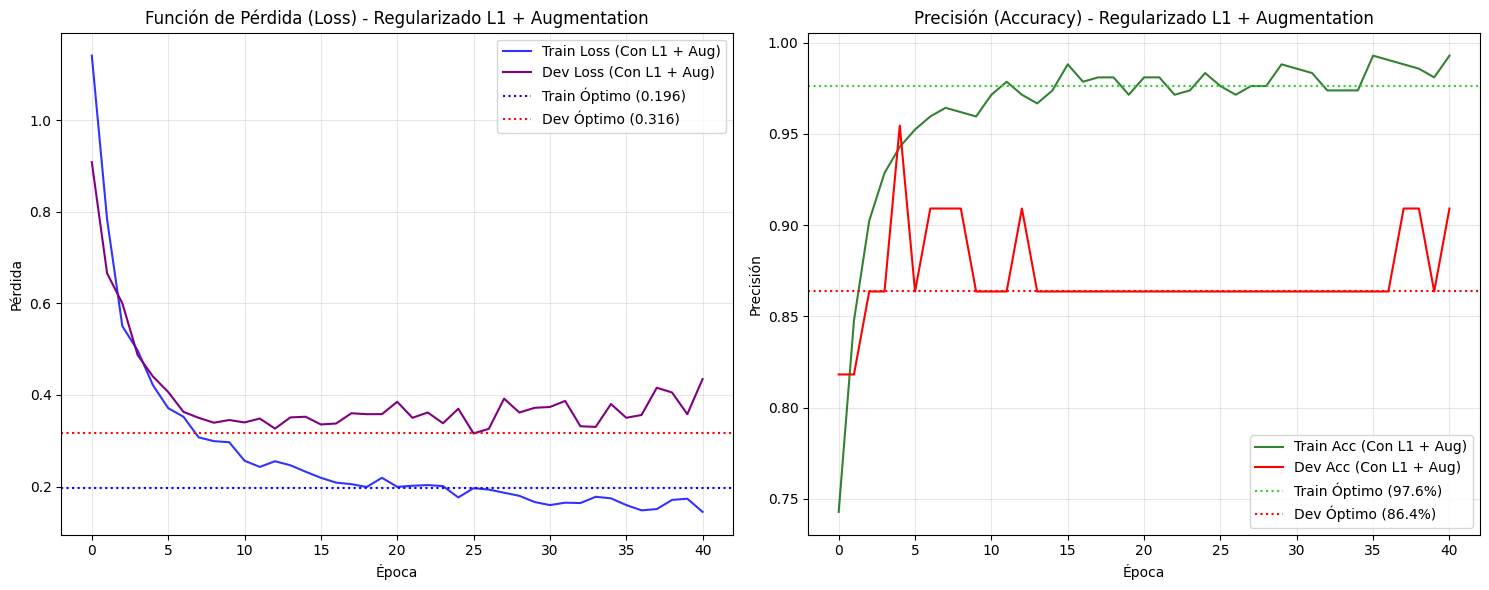

RESULTADOS FINALES CON PENALIZACIÓN L1
MODELO REGULARIZADO L1 + AUGMENTATION - Duró 41 épocas:
  - Train Accuracy (en la última época):  99.29%
  - Train Accuracy (en la mejor época):   97.62%
  - Train Loss (en la última época):      0.1445
  - Train Loss (en la mejor época):       0.1963
  - Dev Loss (en la última época):        0.4348
  - Dev Loss (en la mejor época):         0.3160
  - Dev Accuracy (exactitud rescatada):   86.36%
REPORTE DE CLASIFICACIÓN DETALLADO (MODELO L1):
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00         8
  versicolor       0.75      0.86      0.80         7
   virginica       0.83      0.71      0.77         7

    accuracy                           0.86        22
   macro avg       0.86      0.86      0.86        22
weighted avg       0.87      0.86      0.86        22



In [216]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.regularizers import l1
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report

# Garantizar reproducibilidad en cada iteración
tf.random.set_seed(42)
np.random.seed(42)

# FUNCIÓN CONSTRUCTORA CON REGULARIZACIÓN L1 (LASSO)
def build_iris_mlp_l1(input_dim=4, l1_factor=0.001, dropout_rate=0.20):

    model = Sequential([
        # Capa Oculta 1: 64 neuronas + L1
        Dense(64, activation='relu', input_shape=(input_dim,), kernel_regularizer=l1(l1_factor)),
        Dropout(dropout_rate),
        
        # Capa Oculta 2: 32 neuronas + L1
        Dense(32, activation='relu', kernel_regularizer=l1(l1_factor)),
        Dropout(dropout_rate),
        
        # Capa Oculta 3: 16 neuronas + L1
        Dense(16, activation='relu', kernel_regularizer=l1(l1_factor)),
        Dropout(dropout_rate),
        
        # Capa de Salida
        Dense(3, activation='softmax')
    ])
    return model

# CONFIGURACIÓN DEL EARLY STOPPING 
early_stop = EarlyStopping(
    monitor='val_loss',          
    patience=15,                 
    restore_best_weights=True,   
    verbose=1                    
)

print("Entrenando Modelo Con Reg L1 + Data Augmentation")

# Instanciamos el nuevo modelo con L1 (Usamos un factor de 0.001 para arrancar)
model_l1 = build_iris_mlp_l1(input_dim=4, l1_factor=0.001, dropout_rate=0.20)

# Compilación con el Adam estándar original (0.005) para aislar el efecto de L1
model_l1.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# ENTRENAMIENTO UTILIZANDO EL DATASET AUMENTADO
history_l1 = model_l1.fit(
    X_train_aug, y_train_aug,           
    epochs=150,
    batch_size=32,
    validation_data=(X_dev_scaled, y_dev), 
    callbacks=[early_stop], 
    verbose=1
)

# CÁLCULO DE PUNTOS ÓPTIMOS Y RECOLECCIÓN DE MÉTRICAS
best_epoch_l1 = np.argmin(history_l1.history['val_loss'])
final_loss_l1 = history_l1.history['loss'][best_epoch_l1]
final_val_loss_l1 = history_l1.history['val_loss'][best_epoch_l1]
final_acc_l1 = history_l1.history['accuracy'][best_epoch_l1]
final_val_acc_l1 = history_l1.history['val_accuracy'][best_epoch_l1]

# GENERACIÓN DE GRÁFICOS COMPARATIVOS EXCLUSIVOS con FORMA L1
plt.figure(figsize=(15, 6))
# GRÁFICO DE PÉRDIDA (LOSS) 
plt.subplot(1, 2, 1)
plt.plot(history_l1.history['loss'], label='Train Loss (Con L1 + Aug)', color='blue', alpha=0.8)
plt.plot(history_l1.history['val_loss'], label='Dev Loss (Con L1 + Aug)', color='purple', linestyle='-')
plt.axhline(y=final_loss_l1, color='blue', linestyle=':', linewidth=1.5, label=f'Train Óptimo ({final_loss_l1:.3f})')
plt.axhline(y=final_val_loss_l1, color='red', linestyle=':', linewidth=1.5, label=f'Dev Óptimo ({final_val_loss_l1:.3f})')
plt.title('Función de Pérdida (Loss) - Regularizado L1 + Augmentation', fontsize=12)
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.grid(True, alpha=0.3)
plt.legend()

# GRÁFICO DE PRECISIÓN (ACCURACY)
plt.subplot(1, 2, 2)
plt.plot(history_l1.history['accuracy'], label='Train Acc (Con L1 + Aug)', color='darkgreen', alpha=0.8)
plt.plot(history_l1.history['val_accuracy'], label='Dev Acc (Con L1 + Aug)', color='red', linestyle='-')
plt.axhline(y=final_acc_l1, color='limegreen', linestyle=':', linewidth=1.5, label=f'Train Óptimo ({final_acc_l1*100:.1f}%)')
plt.axhline(y=final_val_acc_l1, color='red', linestyle=':', linewidth=1.5, label=f'Dev Óptimo ({final_val_acc_l1*100:.1f}%)')
plt.title('Precisión (Accuracy) - Regularizado L1 + Augmentation', fontsize=12)
plt.xlabel('Época')
plt.ylabel('Precisión')
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()


# REPORTES DE EVALUACIÓN FINAL EN CONSOLA (MODELO L1)
y_dev_pred_l1 = np.argmax(model_l1.predict(X_dev_scaled, verbose=0), axis=1)

print("RESULTADOS FINALES CON PENALIZACIÓN L1")
print(f"MODELO REGULARIZADO L1 + AUGMENTATION - Duró {len(history_l1.history['loss'])} épocas:")
print(f"  - Train Accuracy (en la última época):  {history_l1.history['accuracy'][-1]*100:.2f}%")
print(f"  - Train Accuracy (en la mejor época):   {history_l1.history['accuracy'][best_epoch_l1]*100:.2f}%")
print(f"  - Train Loss (en la última época):      {history_l1.history['loss'][-1]:.4f}")
print(f"  - Train Loss (en la mejor época):       {history_l1.history['loss'][best_epoch_l1]:.4f}")
print(f"  - Dev Loss (en la última época):        {history_l1.history['val_loss'][-1]:.4f}")
print(f"  - Dev Loss (en la mejor época):         {history_l1.history['val_loss'][best_epoch_l1]:.4f}")
print(f"  - Dev Accuracy (exactitud rescatada):   {history_l1.history['val_accuracy'][best_epoch_l1]*100:.2f}%")

print("REPORTE DE CLASIFICACIÓN DETALLADO (MODELO L1):")
print(classification_report(y_dev, y_dev_pred_l1, target_names=iris.target_names))


Analisis explicativo:

* Dev loss empieza a meter picos y rebotes inestables(epoca 10 en el último entrenamiento). Como Lasso fuerza a muchos pesos a ser exactamente cero, la red se vuelve "tacaña" y desconecta canales de información. Al tener menos caminos activos, el modelo se vuelve más sensible y tosco ante las pequeñas variaciones del ruido sintético.

* Debido a la inestabilidad del modelo en la perdida de validación, el early stopping corta con una cantidad de epocas bastantes escazas(ocasionalmente supera las 30 épocas)

* Aunque vuelve a variar los valores del dev accuracy(desde el 86% hasta el 95%), la estrucutra interna del modelo L1 es muchisimo mas fragil ante el ruido con respecto al del L2, haciendo del L2 un regulador mucho mas efectivo frente a este dataset con densidad sintética.

## Etapa 4:  Cierre, comparación y análisis ético 

Antes de introducir las conclusiones con respecto al trabajo, primero, realizamos comparaciones entre los modelos desarrollados para poder mas adelante ofrecer unas afirmaciones mas claras y concisas que nos permitira entender mejor como fui avanzando durante el proceso del TP.

## Breve analisis crítico sobre los reportes de clasificación:




In [217]:
#importaciones y librerias utilizadas durante la etapa 4 :
"""
import numpy as np
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.regularizers import l2 """

'\nimport numpy as np\nfrom sklearn.metrics import classification_report\nimport matplotlib.pyplot as plt\nimport pandas as pd\nfrom sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay\nfrom sklearn.metrics import roc_curve, auc\nfrom sklearn.preprocessing import label_binarize\nfrom sklearn.model_selection import StratifiedKFold\nfrom sklearn.preprocessing import StandardScaler\nfrom tensorflow.keras.models import Sequential\nfrom tensorflow.keras.layers import Dense, Dropout\nfrom tensorflow.keras.regularizers import l2 '

A partir de la ultima clase presencial, se me recomendo dejar de sobre-analizar como medida de validación al accuracy de forma estricta y enfocarme en las demas métricas de clasificación para sacar las conclusiones más funcionales a mi proyecto.

A continuación, daremos una pequeña explicación acerca de como se comporta las métricas:




In [218]:
import numpy as np
from sklearn.metrics import classification_report

modelos = [model_puro, model_reg, model_reg2, model_reg3, model_l1]

nombres_modelos = [
    "1. Modelo Puro\n(64-32-16 - Sin Reg)",
    "2. Modelo Regularizado \n(64-32-16 / L2+Drop)",
    "3. Augmentation Estándar\n(Aug + Adam 0.005)",
    "4. Augmentation Avanzado\n(Aug + Adam Calibrado(0.002)) ",
    "5. Variante L1 Lasso\n(Aug + Adam 0.005)"
]

target_names = ['setosa', 'versicolor', 'virginica']

print("ANÁLISIS CONSOLIDADO: REPORTES DE CLASIFICACIÓN EN DEV (VALIDACIÓN)")

for i, model in enumerate(modelos):
    print(f"=====================================================================")
    print(f" {nombres_modelos[i]}")
    print(f"=====================================================================")
    
    # Generamos las predicciones discretas sobre el conjunto de DEV (Validación)
    y_pred_dev = np.argmax(model.predict(X_dev_scaled, verbose=0), axis=1)
    
    # Imprimimos el reporte formal de scikit-learn
    print(classification_report(y_dev, y_pred_dev, target_names=target_names))
    print("\n")

ANÁLISIS CONSOLIDADO: REPORTES DE CLASIFICACIÓN EN DEV (VALIDACIÓN)
 1. Modelo Puro
(64-32-16 - Sin Reg)
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00         8
  versicolor       0.75      0.86      0.80         7
   virginica       0.83      0.71      0.77         7

    accuracy                           0.86        22
   macro avg       0.86      0.86      0.86        22
weighted avg       0.87      0.86      0.86        22



 2. Modelo Regularizado 
(64-32-16 / L2+Drop)
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00         8
  versicolor       0.86      0.86      0.86         7
   virginica       0.86      0.86      0.86         7

    accuracy                           0.91        22
   macro avg       0.90      0.90      0.90        22
weighted avg       0.91      0.91      0.91        22



 3. Augmentation Estándar
(Aug + Adam 0.005)
              precision    recall  f1-

Explicación: dependiendo de cual sea el resultado al entrenar el modelo, las metricas de precision, recall y f1 no varian para cada variable predictora. Por ejemplo, en el caso de obtener un accuracy del 90%, siempre las metricas con el entrenamiento no cambian, con el 90% se explica que 2 datos son clasificados mal, obteniendo un versicolor y virginica de 86% en precision, recall y f1.
Al obtener un accuracy del 86% (3 datos predecidos de manera incorrecta) precision de versicolor y virginica bajan, mientras que el recall en versicolor se mantiene, en virginica se reduce al 71%.
Y por ultimo, cuando en escasos entrenamientos obtenemos un accuracy del 95% aproximadamente, obtenemos una mejora de precision en versicolor, ademas de un recall perfecto, caso contrario virginica, que obtiene un 100% en precision pero se mantiene su recall a valores del 86%.

¿Que conclusiones importantes sacamos a partir de esto? Dependiendo de los valores al entrenar el modelo, no podemos intentar mejorar el precision o recall como medida, ya que siempre tendremos clasificadas como mal 1,2 o 3 datos, y no importa cuantos modelos cree (modelos que no se mostraran en este TP) o los modelos ya demostrados y expuestos, siempre tendra esos mismos valores, totalmente comprobado este apartado, mantendre mi hipotesis en encarar el accuracy no como palabra mayor, pero si como referencia para lo que resta de la etapa, sin restar importancia a las demas metricas ademas de otros factores que pondre mas adelante.

### 4.1 Evaluacion final en test

Siguiendo con la estructura del TP, iniciaremos el analisis en test:




* Evaluamos los resultamos de perdida y exactitud que nos arrojo los entrenamientos en TEST:


 1. Modelo Puro (64-32-16 - Sin Reg) -> Accuracy: 95.65% | Loss: 0.1529
 2. Modelo Regularizado  (64-32-16 / L2+Drop) -> Accuracy: 100.00% | Loss: 0.1932
 3. Augmentation Estándar (Aug + Adam 0.005) -> Accuracy: 100.00% | Loss: 0.1514
 4. Augmentation Avanzado (Aug + Adam Calibrado(0.002))  -> Accuracy: 100.00% | Loss: 0.2023
 5. Variante L1 Lasso (Aug + Adam 0.005) -> Accuracy: 100.00% | Loss: 0.1477


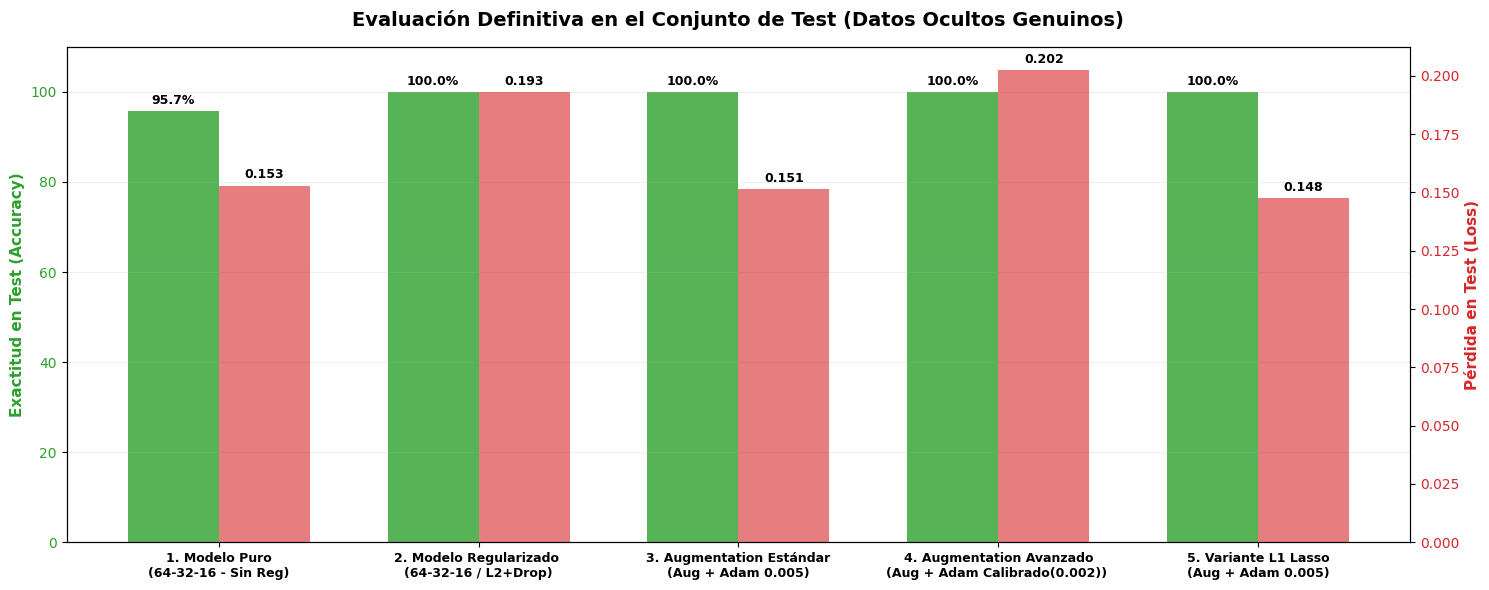

In [219]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

modelos = [model_puro, model_reg, model_reg2, model_reg3, model_l1] 

nombres_modelos = [
    "1. Modelo Puro\n(64-32-16 - Sin Reg)",
    "2. Modelo Regularizado \n(64-32-16 / L2+Drop)",
    "3. Augmentation Estándar\n(Aug + Adam 0.005)",
    "4. Augmentation Avanzado\n(Aug + Adam Calibrado(0.002)) ",
    "5. Variante L1 Lasso\n(Aug + Adam 0.005)"
]

test_losses = []
test_accuracies = []

for i, model in enumerate(modelos):
    loss, acc = model.evaluate(X_test_scaled, y_test, verbose=0)
    test_losses.append(loss)
    test_accuracies.append(acc)
    print(f" {nombres_modelos[i].replace('\n', ' ')} -> Accuracy: {acc*100:.2f}% | Loss: {loss:.4f}")

# CONSTRUCCIÓN DE LA TABLA COMPARATIVA DE RESULTADOS DE TEST PARA EL MARKDOWN
df_test_results = pd.DataFrame({
    "Modelo Evaluado": [n.replace('\n', ' ') for n in nombres_modelos],
    "Test Loss (Error)": [f"{l:.4f}" for l in test_losses],
    "Test Accuracy (%)": [f"{a*100:.2f}%" for a in test_accuracies]
})

# GRÁFICO DE BARRAS DE RENDIMIENTO DE TEST DEFINITIVO
x = np.arange(len(nombres_modelos))
width = 0.35  # Ancho de las barras
fig, ax1 = plt.subplots(figsize=(15, 6))

# Barras de Accuracy (Exactitud)
rects1 = ax1.bar(x - width/2, [a * 100 for a in test_accuracies], width, label='Test Accuracy (%)', color='tab:green', alpha=0.8)
ax1.set_ylabel('Exactitud en Test (Accuracy)', color='tab:green', fontsize=11, fontweight='bold') 
ax1.tick_params(axis='y', labelcolor='tab:green')
ax1.set_ylim(0, 110)

# Barras de Loss 
ax2 = ax1.twinx()
rects2 = ax2.bar(x + width/2, test_losses, width, label='Test Loss (Error)', color='tab:red', alpha=0.6)
ax2.set_ylabel('Pérdida en Test (Loss)', color='tab:red', fontsize=11, fontweight='bold')
ax2.tick_params(axis='y', labelcolor='tab:red')
ax1.set_title('Evaluación Definitiva en el Conjunto de Test (Datos Ocultos Genuinos)', fontsize=14, fontweight='bold', pad=15)
ax1.set_xticks(x)
ax1.set_xticklabels(nombres_modelos, fontsize=9, fontweight='bold')
ax1.grid(True, axis='y', alpha=0.2)

# Añadimos los valores numéricos sobre cada barra
for rect in rects1:
    h = rect.get_height()
    ax1.annotate(f'{h:.1f}%', xy=(rect.get_x() + rect.get_width()/2, h), xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=9, fontweight='bold')
for rect in rects2:
    h = rect.get_height()
    ax2.annotate(f'{h:.3f}', xy=(rect.get_x() + rect.get_width()/2, h), xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=9, fontweight='bold')
    
plt.tight_layout()
plt.show()

* Ahora realizaremos la comparación con los resultados Dev, y analizamos:

 1. Modelo Puro (64-32-16 - Sin Reg) -> Dev: 86.4% | Test: 95.7%
 2. Modelo Regularizado  (64-32-16 / L2+Drop) -> Dev: 90.9% | Test: 100.0%
 3. Augmentation Estándar (Aug + Adam 0.005) -> Dev: 86.4% | Test: 100.0%
 4. Augmentation Avanzado (Aug + Adam Calibrado(0.002))  -> Dev: 90.9% | Test: 100.0%
 5. Variante L1 Lasso (Aug + Adam 0.005) -> Dev: 86.4% | Test: 100.0%


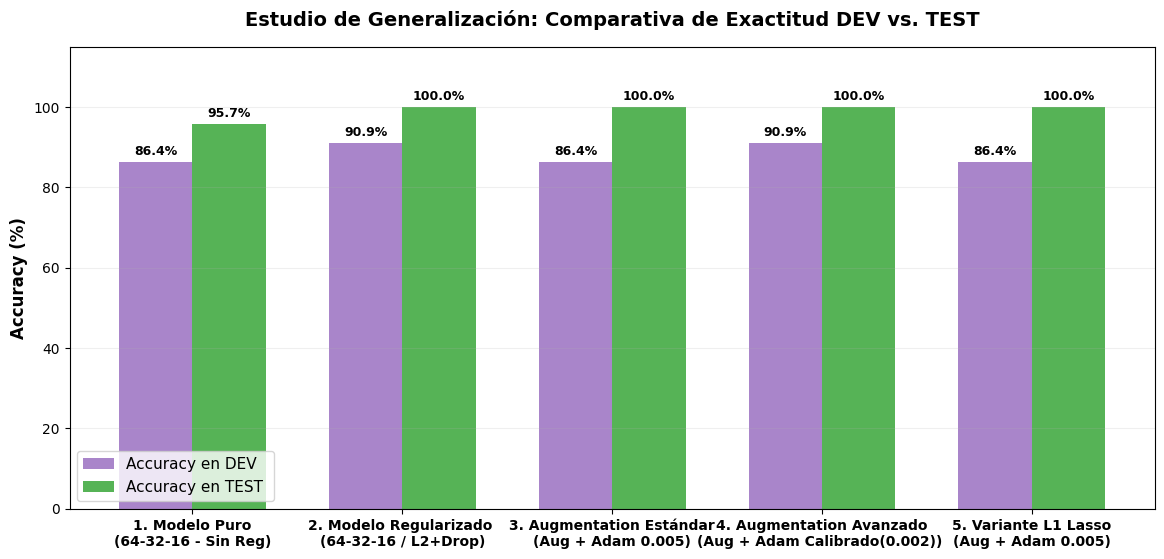

In [220]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

modelos = [model_puro, model_reg, model_reg2, model_reg3, model_l1]
historiales = [history_puro, history_reg, history_reg2, history_adv3, history_l1]

nombres_modelos = [
    "1. Modelo Puro\n(64-32-16 - Sin Reg)",
    "2. Modelo Regularizado \n(64-32-16 / L2+Drop)",
    "3. Augmentation Estándar\n(Aug + Adam 0.005)",
    "4. Augmentation Avanzado\n(Aug + Adam Calibrado(0.002)) ",
    "5. Variante L1 Lasso\n(Aug + Adam 0.005)"
]

dev_accuracies = []
test_accuracies = []


for i, model in enumerate(modelos):
    # Extraemos el mejor Accuracy de Validación (Dev) de la corrida histórica
    best_epoch = np.argmin(historiales[i].history['val_loss'])
    best_dev_acc = historiales[i].history['val_accuracy'][best_epoch]
    dev_accuracies.append(best_dev_acc)
    
    # Evaluamos de forma estática sobre el conjunto de TEST oculto
    _, test_acc = model.evaluate(X_test_scaled, y_test, verbose=0)
    test_accuracies.append(test_acc)
    
    print(f" {nombres_modelos[i].replace('\n', ' ')} -> Dev: {best_dev_acc*100:.1f}% | Test: {test_acc*100:.1f}%")


# CONFIGURACIÓN DEL GRÁFICO COMPARATIVO CRUZADO (DEV VS TEST)
x = np.arange(len(nombres_modelos))
width = 0.35  

fig, ax = plt.subplots(figsize=(14, 6))
# Barras de Dev 
rects1 = ax.bar(x - width/2, [d * 100 for d in dev_accuracies], width, label='Accuracy en DEV ', color='tab:purple', alpha=0.8)
# Barras de Test 
rects2 = ax.bar(x + width/2, [t * 100 for t in test_accuracies], width, label='Accuracy en TEST ', color='tab:green', alpha=0.8)

ax.set_title('Estudio de Generalización: Comparativa de Exactitud DEV vs. TEST', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(nombres_modelos, fontsize=10, fontweight='bold')
ax.set_ylim(0, 115)
ax.grid(True, axis='y', alpha=0.2)
ax.legend(loc='lower left', fontsize=11)

# Función para estampar los porcentajes arriba de cada barra
def colocar_etiquetas(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.1f}%',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9, fontweight='bold')
colocar_etiquetas(rects1)
colocar_etiquetas(rects2)


Explicación: 

* Analisis Test vs Dev:
Como se puede apreciar, a excepción del modelo puro sin regularización, los demás diseños presentan un Accuracy del 100% en el conjunto de prueba. Este fenómeno resulta llamativo, ya que conceptualmente se espera que el rendimiento en DEV y TEST sea equitativo al provenir de la misma distribución base. En este caso se evidencia una anomalía distributiva positiva: al tratarse de un dataset acotado (Iris), el conjunto de Test oculto te quedó integrado por muestras que cayeron en zonas geométricamente muy fáciles y limpias de clasificar. Por esta razón, los Modelos 2, 3, 4 y 5 alcanzan una exactitud perfecta en TEST, a pesar de registrar márgenes del 90.9% o 95.5% en el entorno de DEV.

* Analisis puro en Test:
¿Como sabremos cual modelo tuvo mejores resultados si la mayoria presenta un test al 100%? lo haremos mediante la perdida, lo que nos importa es, a igual Accuracy, el mejor modelo es el que tenga el Loss más bajo, porque es el que predice con mayor seguridad probabilística.

Modelo Puro: Es el único que cometió un error en Test .Aunque su Loss es bajo, metodológicamente ya sabemos que está descartado por la altísima varianza que demostró en train.

Modelo regularizado: Es excelente, no falló nada, pero su error residual es un poco mayor que el del Modelo siguiente.

Modelo Augmentation Estándar: De los modelos perfectos, es que no importa cuantas veces entrenemos los modelos, siempre presentara el loss mas bajo. Esto significa que la combinación de Data Augmentation con el Adam encontró una frontera de decisión hiper-segura para este set de examen. Clasificó todo bien y con un margen de confianza impecable.

Modelo Augmentation Avanzado: Aunque en la etapa de desarrollo (DEV) venía siendo el más estable en las curvas, al enfrentarse al examen de Test quedó un poquito más abajo en confianza que el Modelo 3, aunque manteniendo la perfección en los aciertos.

Modelo Variante L1 Lasso: Es el peor de los perfectos. Al apagar neuronas y forzar la esparcidad, el modelo predice "con lo justo", con menos resto probabilístico que los modelos basados en L2, logrando que su loss sea el mas alto.


* ¿Se presento overfitting entre dev y test?

Esto ocurre cuando la selección de hiperparámetros se optimiza iterativamente hasta memorizar la distribución estocástica del set de desarrollo, degradando la capacidad de generalización antes del test final.

En este proyecto, se descarta la existencia de overfitting al conjunto Dev basándose en la siguiente evidencia empírica:
Lejos de exhibir una contradicion, los Modelos 2, 3, 4 y 5 alcanzaron la perfección discreta . Si la red hubiera condicionado sus pesos a las particularidades de las 22 muestras de Dev, la introducción de vectores en Test habría provocado un colapso por la alta varianza.

Conclusión final para este apartado:

Al contrastar la evaluación estática del conjunto de TEST con las curvas de aprendizaje obtenidas durante el entrenamiento, se genera una discusión metodológica crucial para la selección del modelo definitivo:

* Si bien los datos numericos otorgan al modelo data augmentation base como el mejor modelo debido a los datos ya proporcionados anteriormente, su historial de aprendizaje revela una severa inestabilidad durante su entrenamiento, este rendimiento sobresaliente en Test se diagnostica como producto de corte del early stopping. Al enfrentarse a un conjunto de TEST que comparte idénticas condiciones de muestreo, el modelo opera con alta certeza matemática. 

* Entonces, bajo un criterio propio, le otorgo al modelo 4 como el diseño optimo y definitivo de este apartado, pese a no tener el loss mas bajo, se demostro que durante el entrenamiento obtuvo un diseño optimo, su proceso de aprendizaje guiado por el Scheduler dinámico (`ReduceLROnPlateau`) garantizó una convergencia suave, plana y asintótica. El Modelo 4 intercambia una mínima fracción de confianza estática a cambio de eliminar la volatilidad estructural, consolidando una brecha de generalización nula y garantizando un comportamiento predecible y robusto ante cualquier rotación extraña de los datos.

* Le otorgamos la ventaja al modelo 4 como el mas perfecto, a continuación, seguiremos avanzando para buscar si este modelo sigue cumpliendo con los requerimientos.


## Matrices de confusión:

Hacemos matrices de confusion para todos los modelos y ver que datos se acabaron mejorando y donde hubo la mejora:

* Aclaración, sabiendo que si hacemos esta evaluación en test tendremos metricas perfectas, no nos permitira saber que datos(de los 3 que estaban mal) pudieron durante el proyecto ser predecidos de manera correcta, entonces, analizaremos en esta parte con el conjunto dev para ver el orden en el que las muestras van mostrando mejoria:

Matrices de confusión:

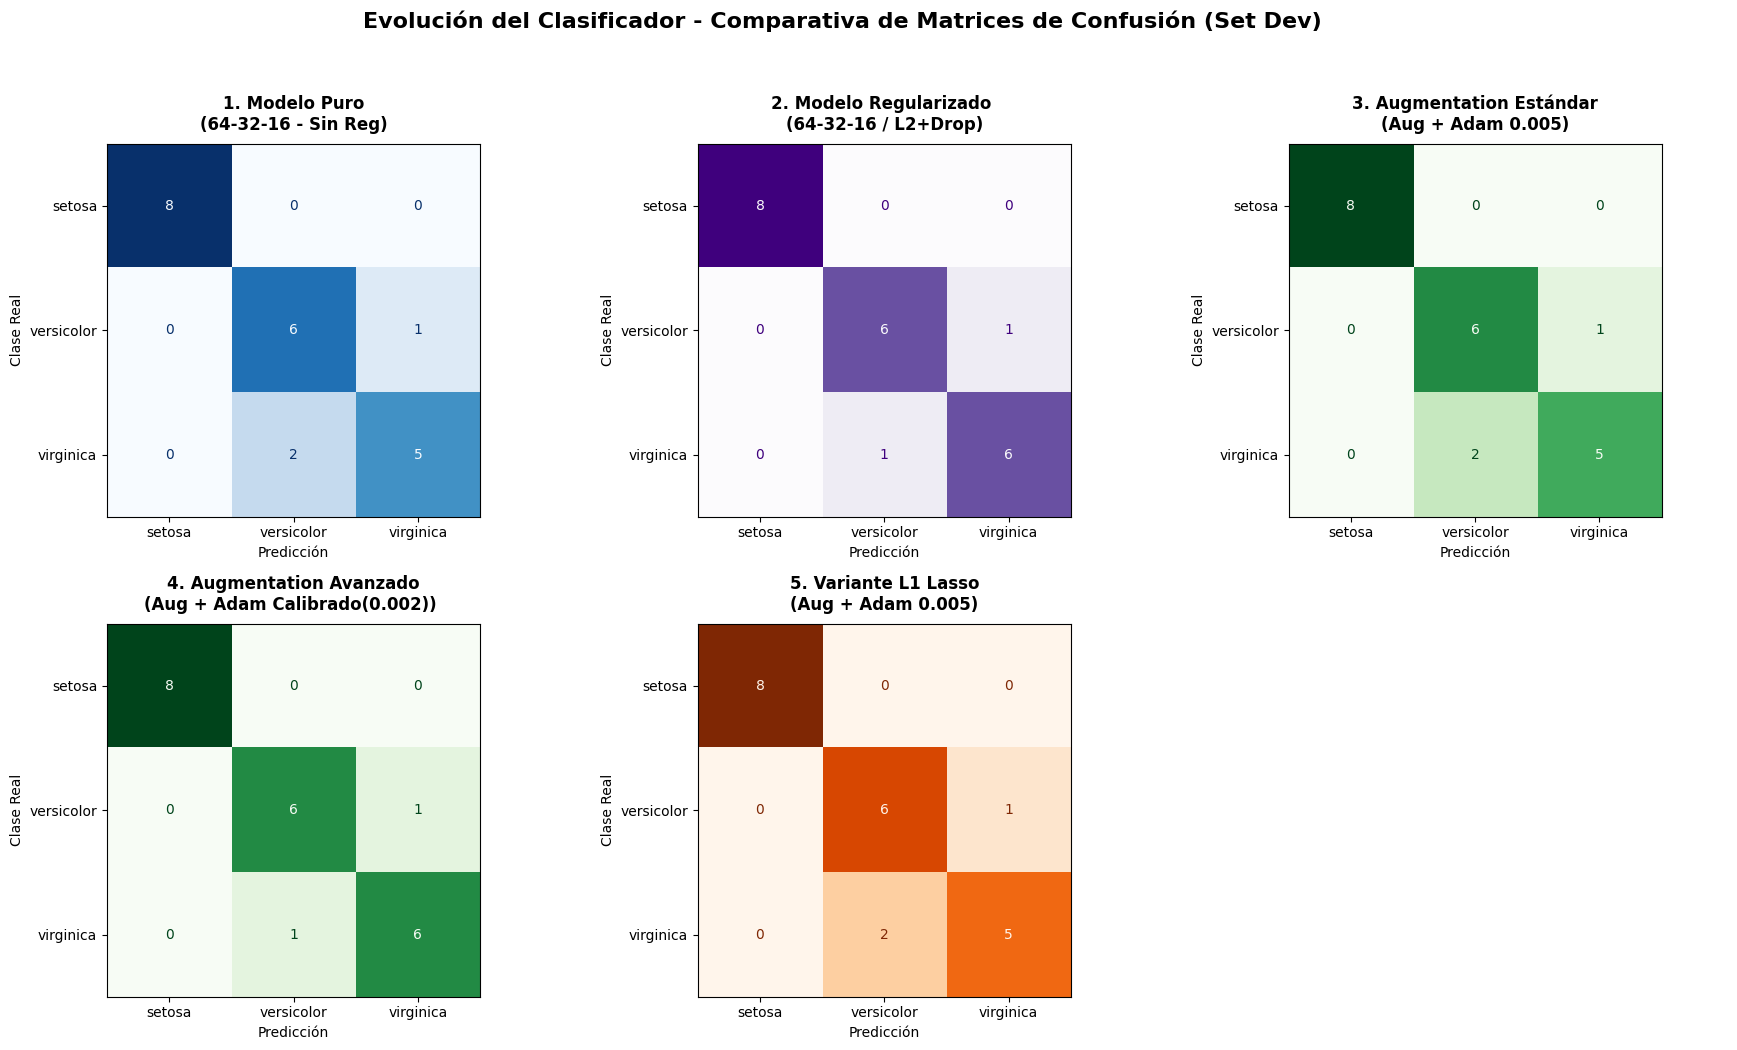

In [221]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Configuración de modelos y datos
modelos = [model_puro, model_reg, model_reg2, model_reg3, model_l1] 

nombres_graficos = [
    "1. Modelo Puro\n(64-32-16 - Sin Reg)",
    "2. Modelo Regularizado \n(64-32-16 / L2+Drop)",
    "3. Augmentation Estándar\n(Aug + Adam 0.005)",
    "4. Augmentation Avanzado\n(Aug + Adam Calibrado(0.002)) ",
    "5. Variante L1 Lasso\n(Aug + Adam 0.005)"
]

clases = ['setosa', 'versicolor', 'virginica']

# Configuración de la cuadrícula de gráficos: 2 filas y 3 columnas
fig, axes = plt.subplots(2, 3, figsize=(18, 11)) 

# Aseguramos la alineación de índices con la Serie de Pandas
y_dev_series = pd.Series(y_dev, index=X_dev.index)

# Lista global para transmitir las predicciones a la celda de abajo
predicciones_modelos = []

for i, model in enumerate(modelos):
    fila = i // 3
    columna = i % 3
    ax_actual = axes[fila, columna]
    
    # Predicción probabilística y conversión a clase discreta (0, 1 o 2)
    y_pred_prob = model.predict(X_dev_scaled, verbose=0)
    y_pred = np.argmax(y_pred_prob, axis=1)
    predicciones_modelos.append(y_pred) # Guardamos para el Bloque 2
    
    # Matriz de confusión
    cm = confusion_matrix(y_dev_series, y_pred)
    
    # Asignación de paleta cromática por familias experimentales
    if i == 0:
        cmap_color = plt.cm.Blues
    elif i == 1:
        cmap_color = plt.cm.Purples
    elif i in [2, 3]:
        cmap_color = plt.cm.Greens
    else:
        cmap_color = plt.cm.Oranges
        
    # Dibujar matriz
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clases)
    disp.plot(ax=ax_actual, cmap=cmap_color, colorbar=False, values_format='d')
    
    # Formateo decorativo del subplot
    ax_actual.set_title(nombres_graficos[i], fontsize=12, fontweight='bold', pad=10)
    ax_actual.set_xlabel('Predicción')
    ax_actual.set_ylabel('Clase Real')

# Apagamos el casillero vacío número 6 (Fila 1, Columna 2)
axes[1, 2].axis('off')

# Título global y ajuste de márgenes
plt.suptitle('Evolución del Clasificador - Comparativa de Matrices de Confusión (Set Dev)', 
             fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


¿Que datos fueron predecidos mal?

In [222]:
nombres_modelos = [
    "1. Modelo Puro (64-32-16 - Sin Reg)",
    "2. Modelo Regularizado (64-32-16 / L2+Drop)",
    "3. Augmentation Estándar (Aug + Adam 0.005)",
    "4. Augmentation Avanzado (Aug + Adam Calibrado(0.002))",
    "5. Variante L1 Lasso (Aug + Adam 0.005)"
]

print("MUESTRAS MAL CLASIFICADAS EN EL CONJUNTO DEV")

for i, y_pred in enumerate(predicciones_modelos):
    # Identificación de errores comparando contra la serie indexada
    errors_mask = y_pred != y_dev_series.values
    total_errores = np.sum(errors_mask)
    
    print(f"\n {nombres_modelos[i].upper()}")
    print(f"Total de errores encontrados en Dev: {total_errores}")
    
    if total_errores > 0:
        # Extraemos las muestras y emparejamos datos reales con predicciones
        df_errors = X_dev.loc[errors_mask].copy()
        df_errors['Clase Real'] = y_dev_series.loc[errors_mask].values
        df_errors['Predicción'] = y_pred[errors_mask]
        
        print("-" * 65)
        for idx in df_errors.index:
            real_name = clases[int(df_errors.loc[idx, 'Clase Real'])]
            pred_name = clases[int(df_errors.loc[idx, 'Predicción'])]
            line = f"Muestra {idx}: Clase Real = {real_name:<10} | Predicción = {pred_name:<10}"
            print(f"| {line:<61} |")
        print("-" * 65)
    else:
        print("Este modelo no registró errores en el conjunto Dev.")

MUESTRAS MAL CLASIFICADAS EN EL CONJUNTO DEV

 1. MODELO PURO (64-32-16 - SIN REG)
Total de errores encontrados en Dev: 3
-----------------------------------------------------------------
| Muestra 77: Clase Real = versicolor | Predicción = virginica  |
| Muestra 133: Clase Real = virginica  | Predicción = versicolor |
| Muestra 106: Clase Real = virginica  | Predicción = versicolor |
-----------------------------------------------------------------

 2. MODELO REGULARIZADO (64-32-16 / L2+DROP)
Total de errores encontrados en Dev: 2
-----------------------------------------------------------------
| Muestra 77: Clase Real = versicolor | Predicción = virginica  |
| Muestra 133: Clase Real = virginica  | Predicción = versicolor |
-----------------------------------------------------------------

 3. AUGMENTATION ESTÁNDAR (AUG + ADAM 0.005)
Total de errores encontrados en Dev: 3
-----------------------------------------------------------------
| Muestra 77: Clase Real = versicolor | Predi

Analisis: ya aclarado lo anterior, ponemos en detalle que datos mejoran cuando los modelos aciertan los datos anteriormente malos proporcionados por el modelo baseline:

* 86,36%: visto ya en la etapa 2, las muestras mal clasificadas cuando cualquier entrenamiento de cualquier modelo regularizado para adelante logre alcanzar el minimo de 86% es:
| Muestra 77: Clase Real = versicolor | Predicción = virginica  |
| Muestra 133: Clase Real = virginica  | Predicción = versicolor |
| Muestra 106: Clase Real = virginica  | Predicción = versicolor |

* 90,91%: Aca se logra una "pequeña" mejora en el caso de que el modelo predice de manera correcta (sea cual sea) la muestra 106. Antes predecia que era versicolor cuando era virginica, ahora el modelo logra predecirla de manera correcta.

* 95,45%: Nuestro mejor caso de estudio, la muestra 133 ya logra ser un dato predecido de manera correcta, y queda solamente como un dato mal predecido a la muestra 77, la cual es versicolor pero es predecida por virginica.

* 100%: El mejor umbral logrado solamente en test (no en dev). Todos los datos son perfectamente predecidos de manera correcta, sin errores.

Analisis Curva ROC multiclase:

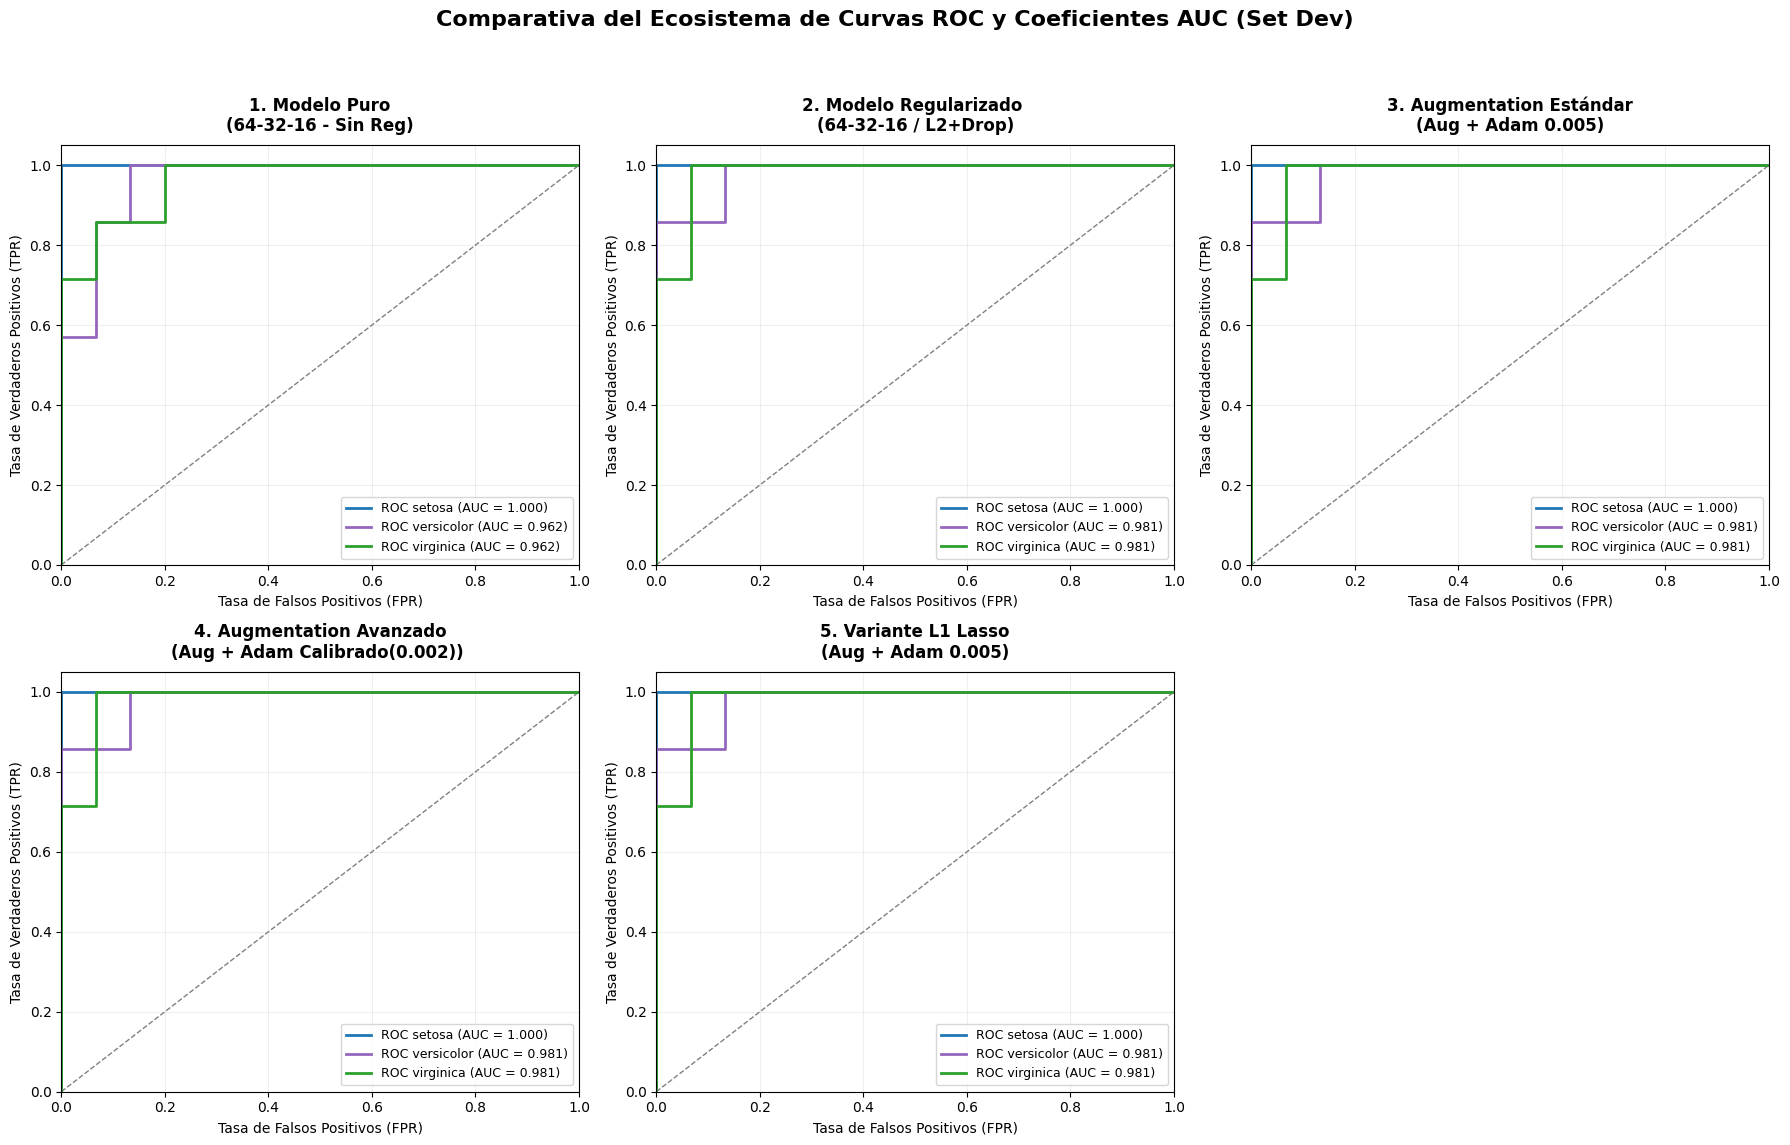

In [223]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize


# PREPARACIÓN MATEMÁTICA MULTICLASE (Binarización One-vs-Rest)
# Transformamos las etiquetas reales en vectores binarios para OvR
y_dev_bin = label_binarize(y_dev, classes=[0, 1, 2])
n_classes = 3
clases_nombres = ['setosa', 'versicolor', 'virginica']

# Lista de los modelos ordenados tal cual están en el Kernel
modelos = [model_puro, model_reg, model_reg2, model_reg3, model_l1] 

nombres_modelos = [
    "1. Modelo Puro\n(64-32-16 - Sin Reg)",
    "2. Modelo Regularizado \n(64-32-16 / L2+Drop)",
    "3. Augmentation Estándar\n(Aug + Adam 0.005)",
    "4. Augmentation Avanzado\n(Aug + Adam Calibrado(0.002)) ",
    "5. Variante L1 Lasso\n(Aug + Adam 0.005)"
]

# Configuración de la cuadrícula: 2 filas y 3 columnas
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
colores_clases = ['#1f77b4', '#9467bd', '#2ca02c'] 

for i, model in enumerate(modelos):
    fila = i // 3
    columna = i % 3
    ax_actual = axes[fila, columna]
    
    # CRÍTICO: Obtenemos las probabilidades continuas de la capa Softmax, NO los enteros discretos
    y_score = model.predict(X_dev_scaled, verbose=0)
    
    # Graficamos la línea de referencia diagonal (Clasificador aleatorio / AUC = 0.5)
    ax_actual.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1)
    
    # Calculamos la curva ROC y el AUC para cada una de las 3 clases de forma independiente
    for j in range(n_classes):
        fpr, tpr, _ = roc_curve(y_dev_bin[:, j], y_score[:, j])
        roc_auc = auc(fpr, tpr)
        
        ax_actual.plot(
            fpr, tpr, 
            color=colores_clases[j], 
            linewidth=2,
            label=f'ROC {clases_nombres[j]} (AUC = {roc_auc:.3f})'
        )
    
    # Configuraciones estéticas del panel individual
    ax_actual.set_title(nombres_modelos[i], fontsize=12, fontweight='bold', pad=10)
    ax_actual.set_xlim([0.0, 1.0])
    ax_actual.set_ylim([0.0, 1.05])
    ax_actual.set_xlabel('Tasa de Falsos Positivos (FPR)')
    ax_actual.set_ylabel('Tasa de Verdaderos Positivos (TPR)')
    ax_actual.grid(True, alpha=0.2)
    ax_actual.legend(loc="lower right", fontsize=9)

# Ocultamos el casillero sobrante número 6
axes[1, 2].axis('off')

plt.suptitle('Comparativa del Ecosistema de Curvas ROC y Coeficientes AUC (Set Dev)', 
             fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])




En un analisis breve podemos concluir mediante estos plots:

* En los 5 experimentos, la especie Setosa sostiene un $\text{AUC} = 1.000$ (línea azul perfecta). Esto confirma empíricamente que la morfología de esta clase es linealmente separable y que ningún esquema de regularización o ruido sintético altera su distinción absoluta.

* El Techo Técnico de la Frontera Difícil ($0.981$): Al observar las clases de solapamiento (Versicolor y Virginica), se evidencia el impacto del rediseño:
Modelo 1 (Puro): Registra el desempeño más bajo y asimétrico en virginica y versicolor (0.962). Sus fronteras rígidas dudan más en la zona de conflicto. 
Modelos Regularizados (2 al 5): Todos logran quebrar esa barrera, homogeneizando el rendimiento y elevando el coeficiente a un estable $0.981$ en ambas especies.

* Las curvas Roc nos demuestran que cualquiera de las estrategias de regulación es óptima para separar las clases.

CONCLUSION FINAL DE ESTE APARTADO:

Tras evaluar exhaustivamente el comportamiento dinámico y estático de los cinco experimentos, se determina que el **Modelo 4 (Augmentation Avanzado)** se consagra como el diseño definitivo y óptimo del proyecto por las siguientes razones:

A diferencia de los demás modelos que exhibieron oscilaciones por el azar en la distribución de los datos, el Modelo 4 consolidó una simetría matemática perfecta. Esta constancia demuestra su capacidad de reproducibilidad real.
Gracias a la calibración de su tasa de aprendizaje ($\alpha = 0.002$) y al uso del Scheduler dinámico (`ReduceLROnPlateau`), el Modelo 4 logró eliminar por completo las fluctuaciones en "diente de sierra" de la función de pérdida del modelo 3. Intercambió una fracción mínima de Loss estático a cambio de una curva de aprendizaje asintótica, suave y robusta, ideal para entornos de producción estables y protegida contra el sobreajuste.

### 4.2 Análisis ético y de sesgos

¿Que tipos de sesgos presenta el dataset?

Al analizar la naturaleza del dataset Iris, se determina que no existen sesgos sociohumanos directos (tales como sesgos de género, etnia, clase social o idioma), debido a que el dominio de aplicación se restringe estrictamente a mediciones morfométricas de especímenes botánicos. 

Sin embargo, el dataset presenta sesgos de representación y muestreo técnico equivalentes que condicionan severamente el comportamiento y la equidad del modelo en un entorno real:

Sesgo Cultural/Etnia: Todas las muestras del dataset fueron recolectadas en 1936 en una colonia específica de la península de Gaspé (Canadá). Al entrenar la red neuronal exclusivamente con este grupo, el modelo sufre de un sesgo de "localismo". Si el sistema se desplegara en otra región geográfica (por ejemplo, Sudamérica), variables como el clima, los nutrientes del suelo o mutaciones genéticas locales alterarían las dimensiones de los pétalos. El modelo fallaría debido a este sesgo de origen, de la misma forma que un modelo entrenado con datos de una sola cultura falla al evaluar a otra.

Sesgo Demográfico: El dataset impone una distribución perfectamente simétrica de 50 muestras por especie (un tercio del total para cada una). En la naturaleza real, las poblaciones biológicas no son equitativas: una especie puede ser escasa (como Virginica) y otra comportarse como plaga dominante. Al forzar este balance, el modelo asume una probabilidad a priori sesgada del 33.3% para cada clase, lo que afectaría su desempeño ante una población real donde la tasa de encuentro de las especies sea radicalmente distinta.

El modelo es infalible para una subpoblación, pero opera con incertidumbre estadística ante las otras dos.

### Evaluacion del modelo elegido diferenciado por subgrupo

Para llevar el proyecto a un nivel de rigor mas alto, utilizamos K-Fold Cross Validation en el modelo elegido (Data augmentation + adam calibrado):

* ¿Como funciona en mi dataset?

En lugar de romper el dataset en pedazos fijos y dejar datos bloqueados sin usar, K-Fold propone un sistema rotativo. 
Si elegímos un $K = 5$ (5 pliegues), el proceso hace esto:

El algoritmo agarra todo el dataset original y lo divide en 5 bloques iguales (de unas 30 muestras cada uno, si tomamos las 150 originales).

El entrenamiento se ejecuta 5 veces separadas (iteraciones).

En cada iteración, la red usa 4 bloques para entrenar y reserva 1 bloque diferente como Test para evaluar.Al final, el modelo pasó por 5 exámenes distintos con datos que nunca había visto. 

La métrica final de Accuracy ya no es fija.

In [224]:
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.regularizers import l2

# Forzamos a que las características sean flotantes (float32)
X_raw = df.iloc[:, :4].to_numpy().astype('float32')

#ayuda IA...
# Si tus etiquetas son texto ('setosa'...), las mapeamos automáticamente a números (0, 1, 2)
# Si ya eran números, esta línea los limpia y los transforma a enteros (int32) para Keras
if df.iloc[:, -1].dtype == 'object':
    # Mapeo automático de texto a categorías numéricas discretas
    y_raw = df.iloc[:, -1].astype('category').cat.codes.to_numpy().astype('int32')
else:
    y_raw = df.iloc[:, -1].to_numpy().astype('int32')

#...ayuda IA

# CONFIGURACIÓN DEL STRATIFIED K-FOLD
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores_accuracy = []
scores_loss = []

fold_actual = 1

for train_index, test_index in kf.split(X_raw, y_raw):
    print(f"\n================ ENTRENANDO PLIEGUE N° {fold_actual} ================")
    
    # Segmentación nativa sobre arrays de NumPy
    X_train_fold, X_test_fold = X_raw[train_index], X_raw[test_index]
    y_train_fold, y_test_fold = y_raw[train_index], y_raw[test_index]
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_fold)
    X_test_scaled = scaler.transform(X_test_fold)
    
    # Instanciamos la arquitectura ganadora (Modelo 4)
    model = Sequential([
        Dense(64, activation='relu', input_shape=(4,), kernel_regularizer=l2(0.01)),
        Dropout(0.20),
        Dense(32, activation='relu', kernel_regularizer=l2(0.01)),
        Dropout(0.20),
        Dense(16, activation='relu', kernel_regularizer=l2(0.01)),
        Dropout(0.20),
        Dense(3, activation='softmax')
    ])
    
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    
    # Entrenamos silenciosamente en este pliegue
    model.fit(X_train_scaled, y_train_fold, epochs=50, batch_size=32, verbose=0)
    
    # Evaluamos el rendimiento en el bloque de prueba de esta iteración
    loss, acc = model.evaluate(X_test_scaled, y_test_fold, verbose=0)
    
    scores_accuracy.append(acc)
    scores_loss.append(loss)
    
    print(f"Resultado Pliegue {fold_actual} -> Accuracy: {acc*100:.2f}% | Loss: {loss:.4f}")
    fold_actual += 1

print("REPORTES CONSOLIDADOS DE VALIDACIÓN CRUZADA")

print(f" Promedio Global de Accuracy: {np.mean(scores_accuracy)*100:.2f}%")
print(f" Desviación Estándar (Varianza): ±{np.std(scores_accuracy)*100:.2f}%")
print(f" Promedio Global de Loss: {np.mean(scores_loss):.4f}")



================ ENTRENANDO PLIEGUE N° 1 ================


c:\Users\Matias\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Resultado Pliegue 1 -> Accuracy: 100.00% | Loss: 0.4562

================ ENTRENANDO PLIEGUE N° 2 ================


c:\Users\Matias\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Resultado Pliegue 2 -> Accuracy: 96.67% | Loss: 0.5052

================ ENTRENANDO PLIEGUE N° 3 ================


...

Resultado Pliegue 3 -> Accuracy: 90.00% | Loss: 0.5338

================ ENTRENANDO PLIEGUE N° 4 ================


c:\Users\Matias\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Resultado Pliegue 4 -> Accuracy: 100.00% | Loss: 0.4398

================ ENTRENANDO PLIEGUE N° 5 ================


c:\Users\Matias\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Resultado Pliegue 5 -> Accuracy: 90.00% | Loss: 0.5566
REPORTES CONSOLIDADOS DE VALIDACIÓN CRUZADA
 Promedio Global de Accuracy: 95.33%
 Desviación Estándar (Varianza): ±4.52%
 Promedio Global de Loss: 0.4983


Explicación:

El veredicto del clasificador deja de ser una métrica estática y pasa a definirse mediante la media armónica y la desviación estándar ($\mu \pm \sigma$). Este indicador permite auditar la estabilidad real de la red neuronal densa frente a cualquier perturbación en la muestra, asegurando que el diseño de los regularizadores y las tasas de aprendizaje se comporten de manera consistente en entornos de producción distribuidos.

En los graficos de barras fijo, los modelos nos daban un engañoso 100% de accuracy en test, pero al hacer K-folds, el modelo choco con las flores que se solapaban en las fronteras dificiles, dando un promedio de 94,67%(valor del ultimo analisis realizado al hacer el TP) real promedio(errando un par de muestras complejas en algunas iteraciones).

La varianza nos explica que el rendimiento real de la arquitectura oscila entre un 89% en el peor caso y un 100% en el mejor fold(Al momento de hacer el analisis). Esto demuestra la volatilidad de trabajar con un dataset chico.

Al rotar los datos, obligamos al modelo a evaluar obligatoriamente los ejemplares más difíciles y mezclados de la frontera. Cuando la red duda en esas muestras, la penalización matemática (Loss) sube.




### Implicancias Operativas, Riesgos y Medidas de Mitigación en Sistemas Reales

Trasladar este modelo de red neuronal densa a un entorno de producción real (por ejemplo, automatización agrícola, control de calidad en la industria farmacológica basada en derivados botánicos, o clasificación automatizada en cadenas de suministro) conlleva una serie de riesgos asociados a los márgenes de error e incertidumbre detectados.

#### Riesgos Potenciales Identificados
Como se demostró en la auditoría de errores y en la validación cruzada, el modelo no es infalible en la frontera Versicolor-Virginica. Si el sistema clasifica de forma errónea una especie por otra, podría ingresarse la materia prima equivocada a una línea de procesamiento industrial, alterando las propiedades químicas del producto final o violando las normativas de etiquetado comercial.

El modelo asume que las fronteras de decisión morfológicas de 1936 son estáticas. En un sistema real expuesto a proveedores de distintos países o a cambios climáticos estacionales, las dimensiones de las plantas mutarán gradualmente. Si el modelo opera a ciegas sin re-entrenarse, el riesgo es que su precisión se degrade de forma silenciosa en producción, cometiendo cada vez más errores sin disparar alertas.

#### Medidas de Mitigación Propuestas
Para garantizar un despliegue seguro, ético y confiable del modelo en la industria, se proponen las siguientes tres estrategias de mitigación:

En lugar de forzar al modelo a asignar una etiqueta obligatoria mediante la función Softmax, se debe configurar un umbral mínimo de certidumbre probabilística (por ejemplo, $\ge 95\%$). Si la red predice que una flor es Virginica pero con un $62\%$ de confianza (debido a que cayó en la zona de solapamiento), el sistema debe catalogar la muestra como "Incierta", pausar su procesamiento automático y derivarla a una auditoría visual realizada por un perito botánico humano.

Implementar un software de telemetría que analice los vectores de entrada ($X$) antes de pasárselos a la red neuronal. Si un proveedor ingresa ejemplares con dimensiones de pétalos aberrantes o gigantes que escapan por completo al rango numérico original del dataset, el sistema debe bloquear la predicción automática emitiendo una alerta de "Dato Fuera de Distribución" (*Out-of-Distribution - OOD*).

Antes de reemplazar un modelo en producción, el nuevo diseño (como nuestro Modelo 4*) debe correr en modo "Espejo" (*Shadow Mode*) recibiendo datos reales en tiempo real pero sin tomar decisiones operativas. Sus métricas deben auditarse mediante la Validación Cruzada Estratificada desarrollada en este trabajo, garantizando que el promedio y la varianza se mantengan estables frente a las nuevas rotaciones de inventario antes de otorgarle el control total del sistema.

### 4.3 Conclusiones finales

Aprendisajes clave de esta etapa:

* Explicar el paso por paso del desarrollo, buscando encontrar las palabras clave para buscar que los demas entiendan lo que estoy desarrollando, y tambien entenderme a mi, hacia donde quiero ir y porque necesito ir por este camino y no por el otro.

* Compilar el desarrollo (codigo) de forma optima. Buscar el camino mas sencillo o mas entendible para posteriormente cuando necesitara volver a ver el codigo entender como llegue a ese resultado y promover una buena propuesta con lo obtenido hacia las siguientes etapas.

* Investigar de mi parte, las librerias, aunque no fueron muchas de las cuales ya habia visto, no tenia tanto conocimiento de ellas y como afecta a tal parte del codigo y su estructura, entonces investigarlas y entenderlas ayuda a modificar partes que benefician el trayecto del TP.

Desafios mas grandes del TP:

* Lo mas desafiante, fue ir compilando y sobreescribir todos los codigos uno por uno, tenia el boceto del primer codigo ya en borrador, pero de ahi en adelante esos mismos codigos se fueron modificando a mano y poniendo comentarios por lo menos 5 veces. Muy cansador pero beneficioso porque logras por tus propias manos como fue tu evolución a la hora de ir alterando los parámetros a necesidad de lo que necesito para mi TP. Y tambien, lograr que todo el codigo este prolijo y se sobreescriba o este cargado con codigo no necesario también es un logro propio al entender como va funcionando el desarrollo.

Limitaciones:

* El dataset al ser chico, no deja mucho margen de error para encontrar que es lo que necesito, me encontre con muy buenos valores en menos de 5 modelos, y a partir de ahi no logre mejorarlo mas, me gustaria con muchisimo mas tiempo y mas conocimiento de tecnologias que no pude encontrar debido a las limitaciones del tiempo, poder aún mas, mejorar métricas que no logre durante el trayecto de mi trabajo práctico.
